--- Detected Column Names After Cleaning ---
['Year', 'Month', 'TNA', 'TSA', 'MGI', 'ATL3']
--------------------------------------------

--- Cleaned Data Sample ---
        Date   TNA   TSA   MGI  ATL3
0 1950-01-01 -0.57 -0.41 -0.17 -0.31
1 1950-02-01 -0.44 -0.31 -0.13 -0.50
2 1950-03-01 -0.62 -0.18 -0.45 -0.54
3 1950-04-01 -0.47 -0.44 -0.03 -0.50
4 1950-05-01 -0.70 -0.85  0.15 -0.05
5 1950-06-01 -0.60 -0.83  0.24 -0.44
6 1950-07-01 -0.73 -0.54 -0.19 -0.82
7 1950-08-01 -0.63 -0.53 -0.10 -1.24
8 1950-09-01 -0.56 -0.63  0.07 -1.53
9 1950-10-01 -0.64 -0.81  0.17 -1.55
---------------------------



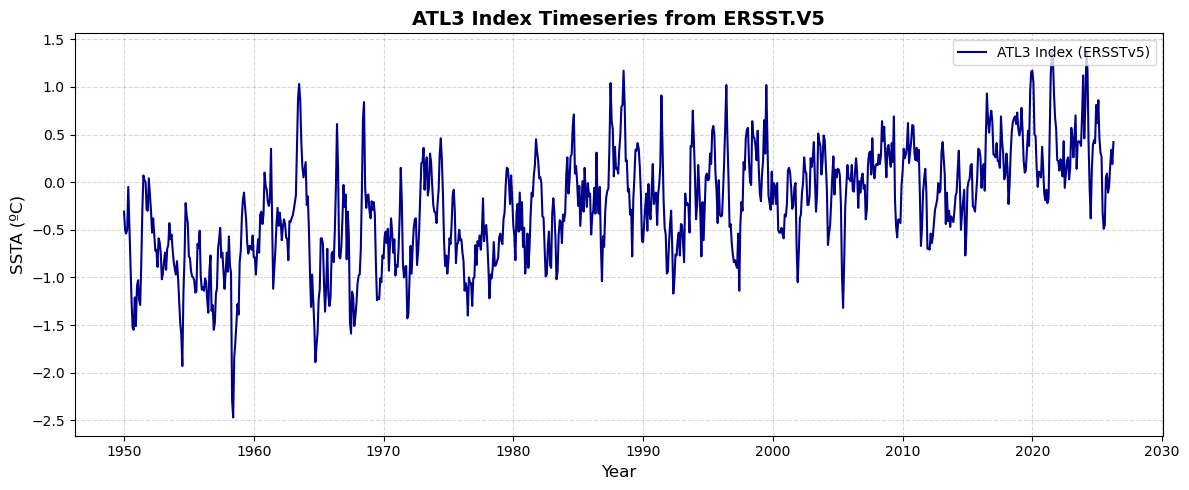

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the updated file path
file_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

# 2. Read the file lines to dynamically find the data header
with open(file_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

# 3. Read data using whitespace delimiter
df = pd.read_csv(file_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

# -------------------------------------------------------------------------
# [CRITICAL FIX] Clean RTF garbage strings using safe string replace functions
# -------------------------------------------------------------------------
# Define a safe cleaner function to strip out RTF tags manually
def clean_rtf_string(s):
    s = str(s)
    # Remove common RTF tags and braces safely without regex escape errors
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

# Clean column names
df.columns = [clean_rtf_string(col) for col in df.columns]

print("--- Detected Column Names After Cleaning ---")
print(list(df.columns))
print("--------------------------------------------\n")

# Clean all data values and convert to float
for col in df.columns:
    df[col] = df[col].apply(clean_rtf_string)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows that failed to parse (like trailing RTF format lines or empty rows)
df = df.dropna(subset=['Year', 'Month', 'ATL3'])

# 4. Create a proper continuous datetime axis
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

print("--- Cleaned Data Sample ---")
print(df[['Date', 'TNA', 'TSA', 'MGI', 'ATL3']].head(10))
print("---------------------------\n")

# 5. Plot the ATL3 Timeseries
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['ATL3'], color='darkblue', linewidth=1.5, label='ATL3 Index (ERSSTv5)')

plt.title("ATL3 Index Timeseries from ERSST.V5", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("SSTA (ºC)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [77]:
import os
import numpy as np
import xarray as xr
import pandas as pd

# =========================================================================
# 1. Configuration
# =========================================================================
models = [
    "CanCM4i", "CanSIPS-IC4", "CanSIPSv2", "CMC1-CanCM3", "CMC2-CanCM4",
    "GEM-NEMO", "GFDL-SPEAR", "NASA-GEOSS2S", "NCAR-CESM1", "NCEP-CFSv2"
]
run_types = ["HINDCAST", "FORECAST"]

base_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME"

all_results = []
merged_results = []

# =========================================================================
# 2. Loop through Models to Compute Spatial Average
# =========================================================================
for model in models:
    model_data = {}  # Store HINDCAST and FORECAST dataframes for the current model
    
    for run_type in run_types:
        target_dir = f"{base_dir}/{model}/SST/ATL3/{run_type}"
        
        if not os.path.exists(target_dir):
            continue
            
        file_pattern = f"{target_dir}/{model}_SST_ATL3_{run_type}_*.nc"
        
        try:
            # open_mfdataset automatically chains the yearly files
            ds = xr.open_mfdataset(file_pattern, combine='by_coords', use_cftime=True)
            
            # Calculate Latitude Weights: cos(lat)
            weights = np.cos(np.deg2rad(ds.Y))
            weights.name = "weights"
            
            # Compute Area-Weighted Mean
            sst_weighted = ds['sst'].weighted(weights)
            atl3_index = sst_weighted.mean(dim=['X', 'Y'])
            
            # Convert to DataFrame and add tracking columns
            df_slice = atl3_index.to_dataframe(name='atl3_sst').reset_index()
            df_slice['model'] = model
            df_slice['run_type'] = run_type
            
            # Save to global list for HINDCAST/FORECAST separate output
            all_results.append(df_slice)
            
            # Save to model-specific dict for the merging process
            model_data[run_type] = df_slice
            
        except Exception as e:
            print(f"--> [ERROR] Failed to process {model} {run_type}: {e}")

    # -----------------------------------------------------------------
    # [NEW] Merge HINDCAST and FORECAST (Priority: HINDCAST > FORECAST)
    # -----------------------------------------------------------------
    if "HINDCAST" in model_data or "FORECAST" in model_data:
        print(f"Creating Merged (Seamless) Dataset for: {model}")
        
        hc = model_data.get("HINDCAST", pd.DataFrame())
        fc = model_data.get("FORECAST", pd.DataFrame())
        
        if hc.empty:
            # If only FORECAST exists
            merged_df = fc.copy()
        elif fc.empty:
            # If only HINDCAST exists
            merged_df = hc.copy()
        else:
            # Both exist: Set indices to align coordinates (S, M, L)
            idx_cols = ['S', 'M', 'L']
            hc_indexed = hc.set_index(idx_cols)
            fc_indexed = fc.set_index(idx_cols)
            
            # Base data is FORECAST, then update/overwrite with HINDCAST wherever available
            # combine_first uses hc values first, and fills missing rows/NaNs with fc values
            merged_indexed = hc_indexed.combine_first(fc_indexed)
            
            merged_df = merged_indexed.reset_index()
            merged_df['model'] = model
            
        # Label this run_type as 'MERGED'
        merged_df['run_type'] = 'MERGED'
        merged_results.append(merged_df)

# =========================================================================
# 3. Merge and Save Final Combined Outputs
# =========================================================================
if all_results:
    print("\nSaving Consolidated Files...")
    
    # Combine HINDCAST, FORECAST, and MERGED dataframes into one mega-dataframe
    final_list = all_results + merged_results
    final_df = pd.concat(final_list, ignore_index=True)
    
    # Reorder columns
    final_df = final_df[['model', 'run_type', 'S', 'M', 'L', 'atl3_sst']]
    
    # Save as CSV
    csv_out = f"{base_dir}/NMME_ATL3_SST_weighted_all_models.csv"
    final_df.to_csv(csv_out, index=False)
    print(f"[SUCCESS] Saved to CSV (Includes MERGED): {csv_out}")
    
    # Save as NetCDF
    # Multidimensional xarray dataset structured by indices
    final_ds = final_df.set_index(['model', 'run_type', 'S', 'M', 'L']).to_xarray()
    nc_out = f"{base_dir}/NMME_ATL3_SST_weighted_all_models.nc"
    final_ds.to_netcdf(nc_out)
    print(f"[SUCCESS] Saved to NetCDF (Includes MERGED): {nc_out}")
    
    # Quick Summary Print
    print("\n--- Data Summary (Row Counts per Run Type) ---")
    print(final_df.groupby(['model', 'run_type']).size())

else:
    print("[ERROR] No data was processed.")

Creating Merged (Seamless) Dataset for: CanCM4i
Creating Merged (Seamless) Dataset for: CanSIPS-IC4
Creating Merged (Seamless) Dataset for: CanSIPSv2
Creating Merged (Seamless) Dataset for: CMC1-CanCM3
Creating Merged (Seamless) Dataset for: CMC2-CanCM4
Creating Merged (Seamless) Dataset for: GEM-NEMO
Creating Merged (Seamless) Dataset for: GFDL-SPEAR
Creating Merged (Seamless) Dataset for: NASA-GEOSS2S
Creating Merged (Seamless) Dataset for: NCAR-CESM1
--> [ERROR] Failed to process NCEP-CFSv2 FORECAST: no files to open
Creating Merged (Seamless) Dataset for: NCEP-CFSv2

Saving Consolidated Files...
[SUCCESS] Saved to CSV (Includes MERGED): /Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.csv


PermissionError: [Errno 13] Permission denied: b'/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc'

In [8]:
final_ds

<xarray.Dataset>
Dimensions:   (model: 10, run_type: 3, S: 557, M: 40, L: 12)
Coordinates:
  * model     (model) object 'CMC1-CanCM3' 'CMC2-CanCM4' ... 'NCEP-CFSv2'
  * run_type  (run_type) object 'FORECAST' 'HINDCAST' 'MERGED'
  * S         (S) object 1980-01-01 00:00:00 ... 2026-05-01 00:00:00
  * M         (M) float32 1.0 2.0 3.0 4.0 5.0 6.0 ... 36.0 37.0 38.0 39.0 40.0
  * L         (L) float32 0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5 10.5 11.5
Data variables:
    atl3_sst  (model, run_type, S, M, L) float32 nan nan nan nan ... nan nan nan

Processing models, calculating SSTA, and generating 4x3 plots...


/var/folders/wf/sg4j3mn13_s608mjkmb6gk_w0000gn/T/ipykernel_97693/1936929227.py:95: RuntimeWarning: Mean of empty slice
  monthly_clim[month] = np.nanmean(sst_values[month_mask, :], axis=0)
/var/folders/wf/sg4j3mn13_s608mjkmb6gk_w0000gn/T/ipykernel_97693/1936929227.py:103: RuntimeWarning: Mean of empty slice
  ens_mean_anom = np.nanmean(ssta_values, axis=1)
/var/folders/wf/sg4j3mn13_s608mjkmb6gk_w0000gn/T/ipykernel_97693/1936929227.py:95: RuntimeWarning: Mean of empty slice
  monthly_clim[month] = np.nanmean(sst_values[month_mask, :], axis=0)
/var/folders/wf/sg4j3mn13_s608mjkmb6gk_w0000gn/T/ipykernel_97693/1936929227.py:103: RuntimeWarning: Mean of empty slice
  ens_mean_anom = np.nanmean(ssta_values, axis=1)
/var/folders/wf/sg4j3mn13_s608mjkmb6gk_w0000gn/T/ipykernel_97693/1936929227.py:95: RuntimeWarning: Mean of empty slice
  monthly_clim[month] = np.nanmean(sst_values[month_mask, :], axis=0)
/var/folders/wf/sg4j3mn13_s608mjkmb6gk_w0000gn/T/ipykernel_97693/1936929227.py:103: RuntimeWa

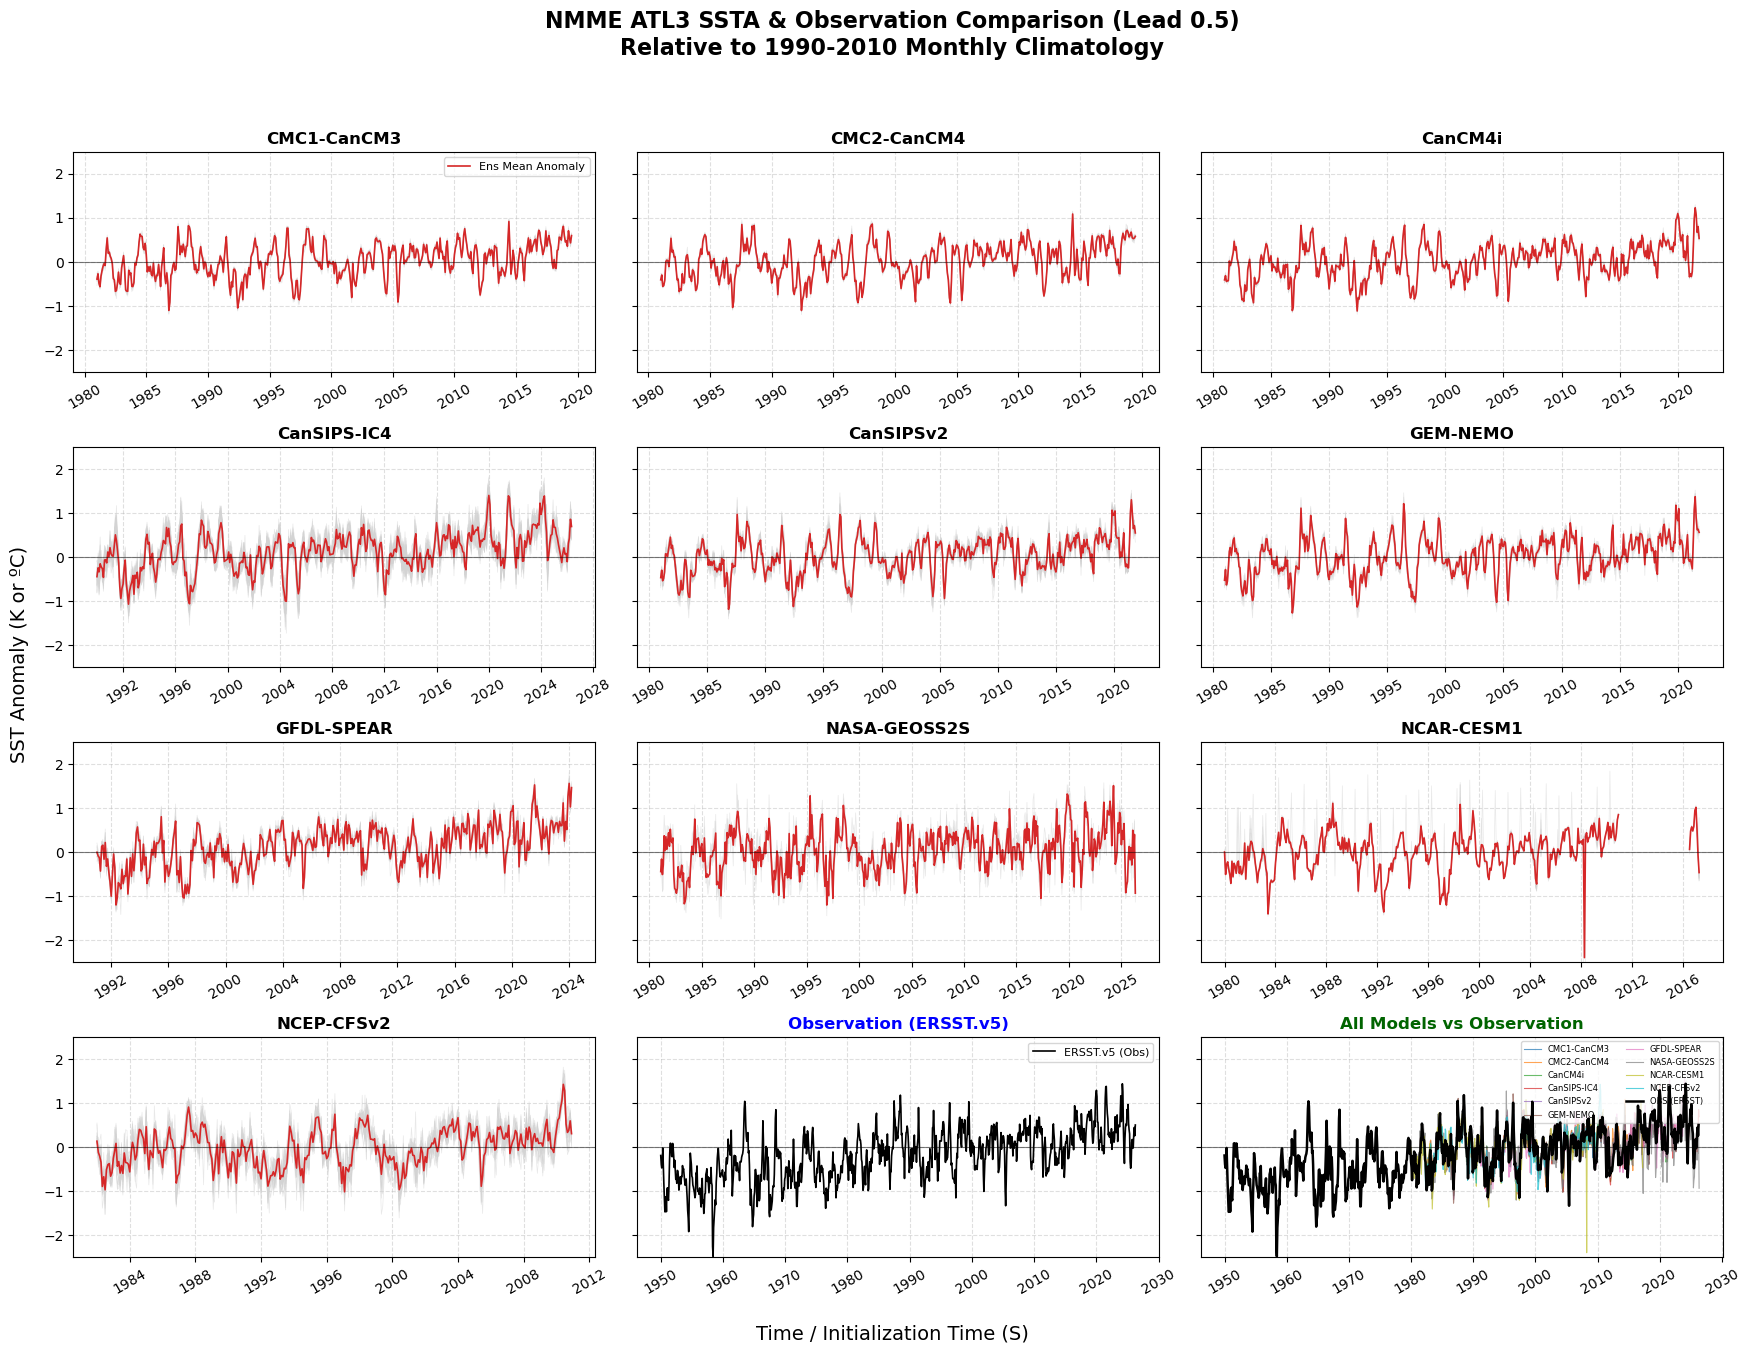

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================================
# 1. Load and Clean Observation Data (RTF Text File)
# =========================================================================
obs_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

with open(obs_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

df_obs = pd.read_csv(obs_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

def clean_rtf_string(s):
    s = str(s)
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

df_obs.columns = [clean_rtf_string(col) for col in df_obs.columns]
for col in df_obs.columns:
    df_obs[col] = df_obs[col].apply(clean_rtf_string)
    df_obs[col] = pd.to_numeric(df_obs[col], errors='coerce')

df_obs = df_obs.dropna(subset=['Year', 'Month', 'ATL3'])
df_obs['Year'] = df_obs['Year'].astype(int)
df_obs['Month'] = df_obs['Month'].astype(int)
df_obs['Date'] = pd.to_datetime(df_obs[['Year', 'Month']].assign(Day=1))

# --- Calculate Monthly Climatology for Observation (1990-2010) ---
obs_clim_mask = (df_obs['Date'] >= "1990-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {}
for m in range(1, 13):
    m_mask = obs_clim_mask & (df_obs['Date'].dt.month == m)
    obs_monthly_clim[m] = df_obs.loc[m_mask, 'ATL3'].mean()

# Subtract Climatology to get Observation SSTA
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Date'].month], axis=1)


# =========================================================================
# 2. Load Model Dataset
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

models = [m for m in ds_merged.model.values if m is not None]

# =========================================================================
# 3. Setup the 4x3 Subplot Grid
# =========================================================================
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 14), sharey=True)
axes = axes.flatten()

print("Processing models, calculating SSTA, and generating 4x3 plots...")

all_model_means = {}

# -------------------------------------------------------------------------
# [CRITICAL FIX] Wrap the entire loop with errstate to completely suppress warnings
# -------------------------------------------------------------------------
with np.errstate(all='ignore'):
    for i, model_name in enumerate(models):
        ax = axes[i]
        
        # Select model data (Lead=0.5)
        mod_ds = ds_merged.sel(model=model_name, L=0.5).sortby('S')
        time_axis_raw = mod_ds['S'].values
        time_axis = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
        
        sst_values = mod_ds['atl3_sst'].values
        if sst_values.ndim == 1:
            sst_values = np.expand_dims(sst_values, axis=1)
            
        num_steps, num_members = sst_values.shape
        ssta_values = np.zeros_like(sst_values)
        
        # --- Calculate Model Monthly Climatology (1990-2010) ---
        clim_years_mask = (time_axis >= "1990-01-01") & (time_axis <= "2010-12-01")
        monthly_clim = {}
        for month in range(1, 13):
            month_mask = clim_years_mask & (time_axis.month == month)
            if month_mask.sum() == 0:
                monthly_clim[month] = np.nanmean(sst_values[time_axis.month == month, :], axis=0)
            else:
                monthly_clim[month] = np.nanmean(sst_values[month_mask, :], axis=0)
                
        # Compute Anomaly
        for t_idx in range(num_steps):
            current_month = time_axis[t_idx].month
            ssta_values[t_idx, :] = sst_values[t_idx, :] - monthly_clim[current_month]
            
        # This nanmean will no longer throw "Mean of empty slice" warnings
        ens_mean_anom = np.nanmean(ssta_values, axis=1)
        
        # Save ensemble mean for Plot 12
        all_model_means[model_name] = (time_axis, ens_mean_anom)
        
        # Plot Plot 1 to 10: Individual Members & Ensemble Mean
        for m_idx in range(num_members):
            ax.plot(time_axis, ssta_values[:, m_idx], color='lightgray', linewidth=0.5, alpha=0.5)
        if not np.isnan(ens_mean_anom).all():
            ax.plot(time_axis, ens_mean_anom, color='tab:red', linewidth=1.2, label='Ens Mean Anomaly')
            
        ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        ax.set_ylim(-2.5, 2.5)
        ax.set_title(model_name, fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(axis='x', rotation=30)
        if i == 0:
            ax.legend(loc='upper right', fontsize=8)

# =========================================================================
# 4. 11th Plot: Observation Only (ERSST.v5)
# =========================================================================
ax_obs = axes[10]
ax_obs.plot(df_obs['Date'], df_obs['ATL3_SSTA'], color='black', linewidth=1.2, label='ERSST.v5 (Obs)')
ax_obs.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax_obs.set_ylim(-2.5, 2.5)
ax_obs.set_title("Observation (ERSST.v5)", fontsize=12, fontweight='bold', color='blue')
ax_obs.grid(True, linestyle='--', alpha=0.4)
ax_obs.tick_params(axis='x', rotation=30)
ax_obs.legend(loc='upper right', fontsize=8)

# =========================================================================
# 5. 12th Plot: Multi-Model Ensemble vs Observation (All Together)
# =========================================================================
ax_all = axes[11]
# Plot all models as thin colored lines
for model_name, (t_ax, m_val) in all_model_means.items():
    ax_all.plot(t_ax, m_val, linewidth=0.8, alpha=0.7, label=model_name)

# Overlay Observation as a thick black line to stand out
ax_all.plot(df_obs['Date'], df_obs['ATL3_SSTA'], color='black', linewidth=1.8, label='OBS (ERSST)', zorder=10)
ax_all.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax_all.set_ylim(-2.5, 2.5)
ax_all.set_title("All Models vs Observation", fontsize=12, fontweight='bold', color='darkgreen')
ax_all.grid(True, linestyle='--', alpha=0.4)
ax_all.tick_params(axis='x', rotation=30)

# Put a small scrollable or tightly packed legend for the 12th plot
ax_all.legend(loc='upper right', fontsize=6, ncol=2)

# =========================================================================
# 6. Global Labels and Adjustments
# =========================================================================
fig.suptitle("NMME ATL3 SSTA & Observation Comparison (Lead 0.5)\nRelative to 1990-2010 Monthly Climatology", fontsize=16, fontweight='bold', y=0.96)

fig.text(0.5, 0.01, 'Time / Initialization Time (S)', ha='center', fontsize=14)
fig.text(0.01, 0.5, 'SST Anomaly (K or ºC)', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.93])
plt.show()

Step 1: Loading and preprocessing observation data...
Step 2: Loading GFDL-SPEAR and calculating SSTA...
Step 3: Generating 2-panel comparison plot...
Done! Plot is displayed.


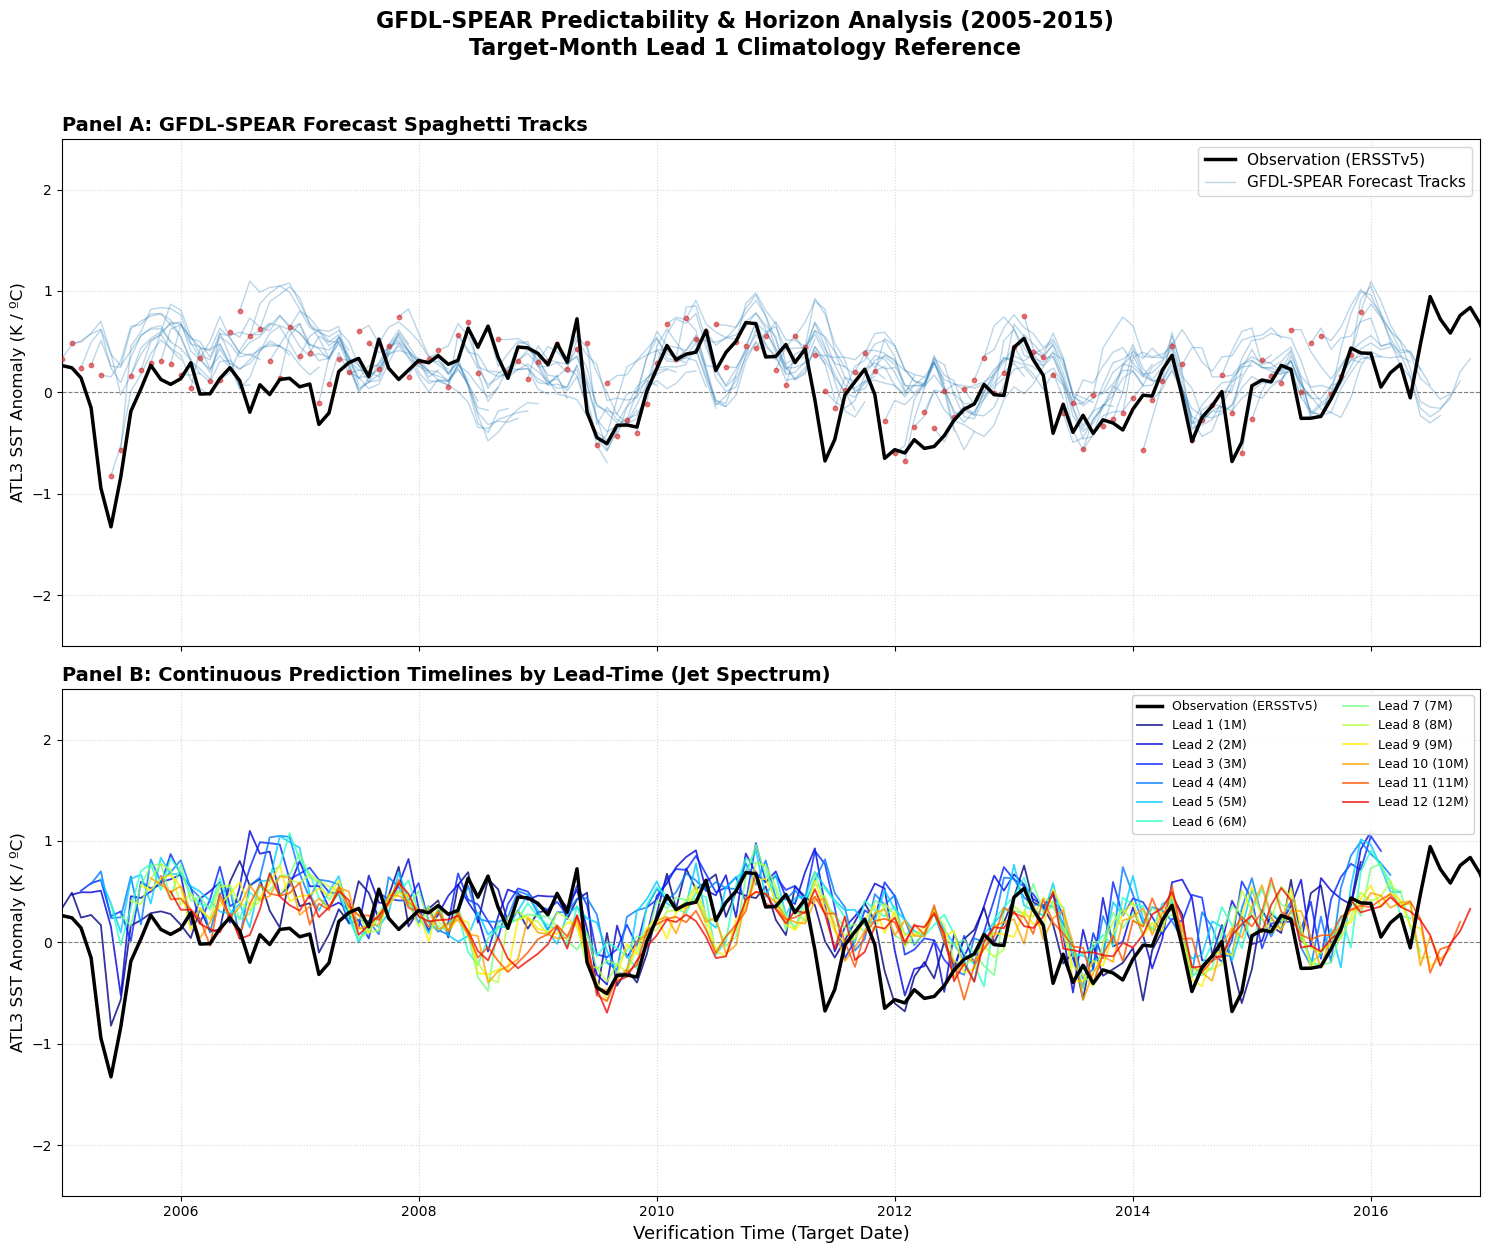

In [29]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================================
# 1. Load and Clean Observation Data (ERSST.v5)
# =========================================================================
obs_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

print("Step 1: Loading and preprocessing observation data...")
with open(obs_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

df_obs = pd.read_csv(obs_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

def clean_rtf_string(s):
    s = str(s)
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

df_obs.columns = [clean_rtf_string(col) for col in df_obs.columns]
for col in df_obs.columns:
    df_obs[col] = df_obs[col].apply(clean_rtf_string)
    df_obs[col] = pd.to_numeric(df_obs[col], errors='coerce')

df_obs = df_obs.dropna(subset=['Year', 'Month', 'ATL3'])
df_obs['Date'] = pd.to_datetime(df_obs[['Year', 'Month']].assign(Day=1))

# Obs 1990-2010 Monthly Climatology
obs_clim_mask = (df_obs['Date'] >= "1990-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {m: df_obs.loc[obs_clim_mask & (df_obs['Date'].dt.month == m), 'ATL3'].mean() for m in range(1, 13)}
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Date'].month], axis=1)


# =========================================================================
# 2. Load GFDL-SPEAR and Compute Climatology BASED ONLY ON LEAD 1 (L=0.5)
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"

print("Step 2: Loading GFDL-SPEAR and calculating SSTA...")
ds_all = xr.open_dataset(nc_path)
ds_gfdl = ds_all.sel(model="GFDL-SPEAR", run_type="MERGED").sortby('S')

# Translate cftime to standard pandas DatetimeIndex properly
time_axis_raw = ds_gfdl['S'].values
time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
ds_gfdl = ds_gfdl.assign_coords(S=time_axis_S)

leads = ds_gfdl.L.values  
gfdl_ssta = ds_gfdl['atl3_sst'].copy(deep=True)  # Core shape: (S, M, L)

# Get 1-12 Month Climatology using ONLY Lead 1 (L=0.5) during 1990-2010
baseline_ds_l1 = ds_gfdl.sel(S=slice("1990-01-01", "2010-12-01"), L=0.5)

with np.errstate(all='ignore'):
    l1_master_clim = baseline_ds_l1['atl3_sst'].groupby('S.month').mean(dim='S')

# Safe Numpy-level array mapping to prevent dimension explosion
clim_np_matrix = l1_master_clim.values  

for l_idx, lead in enumerate(leads):
    target_months = ds_gfdl['S'].dt.month + int(lead)
    target_months = np.where(target_months > 12, target_months - 12, target_months)
    
    current_lead_vals = ds_gfdl['atl3_sst'].sel(L=lead).values 
    mapped_clim_np = clim_np_matrix[target_months - 1]  
    
    gfdl_ssta.loc[dict(L=lead)] = current_lead_vals - mapped_clim_np

# Calculate Ensemble Mean across members (M) -> Dimensions left: (S, L)
gfdl_ens_mean_anom = gfdl_ssta.mean(dim='M')


# =========================================================================
# 3. Plotting the 2-Panel (1x2 Rows) Predictability Plot
# =========================================================================
print("Step 3: Generating 2-panel comparison plot...")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 13), sharex=True, sharey=True)

plot_start_year = 2005
plot_end_year = 2015

# Filter initialization time index for Panel 1
plot_S = ds_gfdl['S'].values
filtered_S = plot_S[(plot_S >= pd.Timestamp(f"{plot_start_year}-01-01")) & (plot_S <= pd.Timestamp(f"{plot_end_year}-12-01"))]

# -------------------------------------------------------------------------
# Panel A (Top): Classical Spaghetti Plot
# -------------------------------------------------------------------------
axes[0].plot(df_obs['Date'], df_obs['ATL3_SSTA'], color='black', linewidth=2.5, label='Observation (ERSSTv5)', zorder=5)

first_trajectory_labeled = False
for S_time in filtered_S:
    S_pd = pd.Timestamp(S_time)
    trajectory_dates = [S_pd + pd.DateOffset(months=int(l)) for l in leads]
    traj_values = gfdl_ens_mean_anom.sel(S=S_time).values
    
    if not first_trajectory_labeled:
        axes[0].plot(trajectory_dates, traj_values, color='tab:blue', alpha=0.3, linewidth=1.0, label='GFDL-SPEAR Forecast Tracks')
        first_trajectory_labeled = True
    else:
        axes[0].plot(trajectory_dates, traj_values, color='tab:blue', alpha=0.3, linewidth=1.0)
    
    axes[0].scatter(trajectory_dates[0], traj_values[0], color='tab:red', s=10, alpha=0.6, zorder=4)

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title("Panel A: GFDL-SPEAR Forecast Spaghetti Tracks", fontsize=14, fontweight='bold', loc='left')
axes[0].legend(loc='upper right', fontsize=11)


# -------------------------------------------------------------------------
# Panel B (Bottom): Continuous Lead-time Lines via 'jet' Colormap
# -------------------------------------------------------------------------
axes[1].plot(df_obs['Date'], df_obs['ATL3_SSTA'], color='black', linewidth=2.5, label='Observation (ERSSTv5)', zorder=5)

# Extract colormap spectrum for 12 lines
cmap = plt.get_cmap('jet')
colors = [cmap(i) for i in np.linspace(0, 0.9, len(leads))] # 0 to 0.9 handles blue to clear red

# Draw a single continuous line across time for EACH lead time
for l_idx, lead in enumerate(leads):
    # For a specific lead time, we extract data for ALL initializations in the time window
    # To compare with observation, the data's X-axis MUST be shifted to target verification dates:
    # Target Verification Date = Initialization Date (S) + Lead time month
    lead_series = gfdl_ens_mean_anom.sel(L=lead)
    
    # Slice the series according to initialization window boundaries
    sliced_lead_series = lead_series.sel(S=slice(f"{plot_start_year}-01-01", f"{plot_end_year}-12-01"))
    
    # Calculate the verification target dates for this entire timeline array
    # Shifting every S date forward by int(lead) months
    verification_dates = [pd.Timestamp(s) + pd.DateOffset(months=int(lead)) for s in sliced_lead_series['S'].values]
    
    # Plot the continuous curve for Lead {l_idx+1}
    axes[1].plot(verification_dates, sliced_lead_series.values, 
                 color=colors[l_idx], linewidth=1.3, alpha=0.8,
                 label=f'Lead {l_idx+1} ({int(lead)+1}M)')

axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title("Panel B: Continuous Prediction Timelines by Lead-Time (Jet Spectrum)", fontsize=14, fontweight='bold', loc='left')

# Format a tight, readable legend for 12 lines in 2 columns
axes[1].legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.9)


# --------------------------------=========================================
# Global Layout adjustments
# --------------------------------=========================================
for ax in axes:
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_ylabel("ATL3 SST Anomaly (K / ºC)", fontsize=12)

axes[1].set_xlabel("Verification Time (Target Date)", fontsize=13)
plt.xlim(pd.Timestamp(f"{plot_start_year}-01-01"), pd.Timestamp(f"{plot_end_year+1}-12-01"))

fig.suptitle("GFDL-SPEAR Predictability & Horizon Analysis (2005-2015)\nTarget-Month Lead 1 Climatology Reference", fontsize=16, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.94])
print("Done! Plot is displayed.")
plt.show()

Step 1: Loading and preprocessing observation data...
Step 3: Calculating Persistence skill...
Step 4: Processing individual models and calculating ACC...
Step 5: Computing Multi-Model Ensemble (MME) skill...
Step 6: Generating skill plots...
All tasks completed successfully!


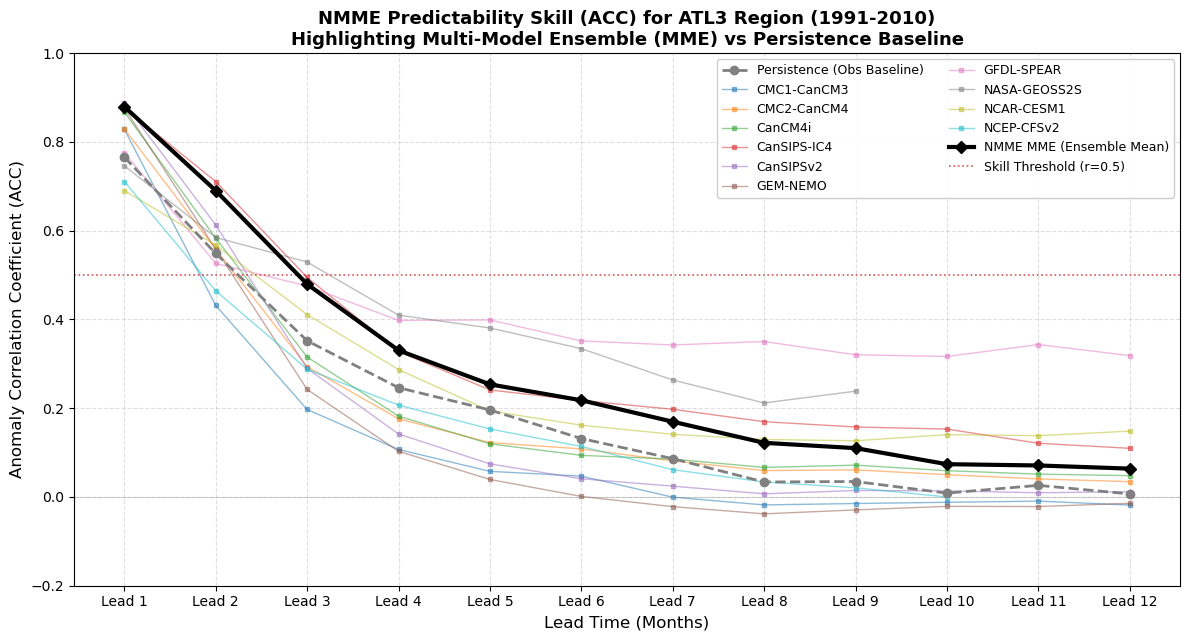

In [34]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# =========================================================================
# 1. Load and Clean Observation Data (ERSST.v5)
# =========================================================================
obs_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

print("Step 1: Loading and preprocessing observation data...")
with open(obs_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

df_obs = pd.read_csv(obs_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

def clean_rtf_string(s):
    s = str(s)
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

df_obs.columns = [clean_rtf_string(col) for col in df_obs.columns]
for col in df_obs.columns:
    df_obs[col] = df_obs[col].apply(clean_rtf_string)
    df_obs[col] = pd.to_numeric(df_obs[col], errors='coerce')

df_obs = df_obs.dropna(subset=['Year', 'Month', 'ATL3'])
df_obs['Date'] = pd.to_datetime(df_obs[['Year', 'Month']].assign(Day=1))

obs_clim_mask = (df_obs['Date'] >= "1991-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {m: df_obs.loc[obs_clim_mask & (df_obs['Date'].dt.month == m), 'ATL3'].mean() for m in range(1, 13)}
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Date'].month], axis=1)
df_obs_indexed = df_obs.set_index('Date')


# =========================================================================
# 2. Load Model Dataset & Settings
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

models = [m for m in ds_merged.model.values if m is not None]
leads = ds_merged.L.values  

start_eval = pd.Timestamp("1991-01-01")
end_eval = pd.Timestamp("2010-12-01")

model_skills = {model: [] for model in models}
persistence_skills = []

# Dictionary to collect raw ensemble mean time series for MME calculation
# Key: model_name, Value: DataArray of shape (S, L)
model_anom_dict = {}


# =========================================================================
# 3. Compute Persistence Forecast Skill
# =========================================================================
print("Step 3: Calculating Persistence skill...")
with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        obs_predictor_list = []
        obs_target_list = []
        df_period = df_obs[(df_obs['Date'] >= start_eval) & (df_obs['Date'] <= end_eval)]
        
        for _, row in df_period.iterrows():
            init_date = row['Date']
            persistence_anchor_date = init_date - pd.DateOffset(months=1)
            target_date = init_date + pd.DateOffset(months=int(lead))
            
            if (persistence_anchor_date in df_obs_indexed.index) and (target_date in df_obs_indexed.index):
                obs_predictor_list.append(df_obs_indexed.loc[persistence_anchor_date, 'ATL3_SSTA'])
                obs_target_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
                
        if len(obs_predictor_list) > 10:
            r_val, _ = pearsonr(obs_predictor_list, obs_target_list)
            persistence_skills.append(r_val)
        else:
            persistence_skills.append(np.nan)


# =========================================================================
# 4. Compute Model Forecast Skills & Save Data for MME
# =========================================================================
print("Step 4: Processing individual models and calculating ACC...")
for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    # Lead 1 Climatology
    baseline_ds_l1 = ds_mod.sel(S=slice(start_eval, end_eval), L=0.5)
    with np.errstate(all='ignore'):
        l1_master_clim = baseline_ds_l1['atl3_sst'].groupby('S.month').mean(dim='S')
    clim_np_matrix = l1_master_clim.values  
    
    # Anomaly
    gfdl_ssta = ds_mod['atl3_sst'].copy(deep=True)
    for l_idx, lead in enumerate(leads):
        target_months = ds_mod['S'].dt.month + int(lead)
        target_months = np.where(target_months > 12, target_months - 12, target_months)
        current_lead_vals = ds_mod['atl3_sst'].sel(L=lead).values 
        mapped_clim_np = clim_np_matrix[target_months - 1]  
        gfdl_ssta.loc[dict(L=lead)] = current_lead_vals - mapped_clim_np
        
    ens_mean_anom = gfdl_ssta.mean(dim='M')
    
    # Save sliced evaluation array for MME later
    model_anom_dict[model_name] = ens_mean_anom.sel(S=slice(start_eval, end_eval))
    
    # Calculate Individual Model ACC
    eval_model_anom = model_anom_dict[model_name]
    eval_S_dates = eval_model_anom['S'].values
    
    with np.errstate(all='ignore'):
        for l_idx, lead in enumerate(leads):
            model_vals_list = []
            obs_vals_list = []
            for S_time in eval_S_dates:
                S_pd = pd.Timestamp(S_time)
                target_date = S_pd + pd.DateOffset(months=int(lead))
                if target_date in df_obs_indexed.index:
                    model_vals_list.append(eval_model_anom.sel(S=S_time, L=lead).values.item())
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
            
            if len(model_vals_list) > 10 and not np.isnan(model_vals_list).all():
                r_val, _ = pearsonr(model_vals_list, obs_vals_list)
                model_skills[model_name].append(r_val)
            else:
                model_skills[model_name].append(np.nan)


# =========================================================================
# 5. Compute Multi-Model Ensemble (MME) Mean Skill
# =========================================================================
print("Step 5: Computing Multi-Model Ensemble (MME) skill...")
mme_skills = []

with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        mme_vals_list = []
        obs_vals_list = []
        
        for S_time in eval_S_dates:
            S_pd = pd.Timestamp(S_time)
            target_date = S_pd + pd.DateOffset(months=int(lead))
            
            if target_date in df_obs_indexed.index:
                # Gather forecast values from all available models at this specific S and L
                step_forecasts = []
                for model_name in models:
                    mod_anom = model_anom_dict[model_name]
                    # Ensure the timestep exists in this specific model
                    if S_time in mod_anom['S'].values:
                        val = mod_anom.sel(S=S_time, L=lead).values.item()
                        if not np.isnan(val):
                            step_forecasts.append(val)
                
                # If at least one model has a forecast, average them to get the MME forecast
                if len(step_forecasts) > 0:
                    mme_vals_list.append(np.mean(step_forecasts))
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
        
        # Calculate Correlation for MME
        if len(mme_vals_list) > 10:
            r_val, _ = pearsonr(mme_vals_list, obs_vals_list)
            mme_skills.append(r_val)
        else:
            mme_skills.append(np.nan)


# =========================================================================
# 6. Plotting the Ultimate Comparison Plot
# =========================================================================
print("Step 6: Generating skill plots...")
plt.figure(figsize=(12, 6.5))
lead_months = np.arange(1, len(leads) + 1)

# 6a. Plot Persistence Baseline (Requested: Gray, Dashed)
plt.plot(lead_months, persistence_skills, color='gray', linewidth=2.0, 
         linestyle='--', marker='o', label='Persistence (Obs Baseline)', zorder=8)

# 6b. Plot Individual Models (Thin Alpha lines to highlight MME)
for model_name, skills in model_skills.items():
    if not np.isnan(skills).all():
        plt.plot(lead_months, skills, linewidth=1.0, marker='s', markersize=3, alpha=0.5, label=model_name)

# 6c. Plot Multi-Model Ensemble Mean Skill (Requested: Black, Solid, Thick)
plt.plot(lead_months, mme_skills, color='black', linewidth=3.0, 
         linestyle='-', marker='D', markersize=6, label='NMME MME (Ensemble Mean)', zorder=15)

# Formatting Layout
plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.3)
plt.axhline(0.5, color='tab:red', linestyle=':', linewidth=1.2, alpha=0.8, label='Skill Threshold (r=0.5)')

plt.title(f"NMME Predictability Skill (ACC) for ATL3 Region (1991-2010)\nHighlighting Multi-Model Ensemble (MME) vs Persistence Baseline", fontsize=13, fontweight='bold')
plt.xlabel("Lead Time (Months)", fontsize=12)
plt.ylabel("Anomaly Correlation Coefficient (ACC)", fontsize=12)

plt.xticks(lead_months, [f"Lead {m}" for m in lead_months])
plt.ylim(-0.2, 1.0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
print("All tasks completed successfully!")
plt.show()

Step 1: Loading and preprocessing observation data...
Step 3: Calculating Persistence Target-Season skill (1982-2010)...
Step 4: Processing individual models with separate lead-climatologies...
Step 5: Computing NMME MME Target-Season skill from purified anomalies...
Step 6: Generating high-fidelity target-season plot...
All tasks processed successfully.


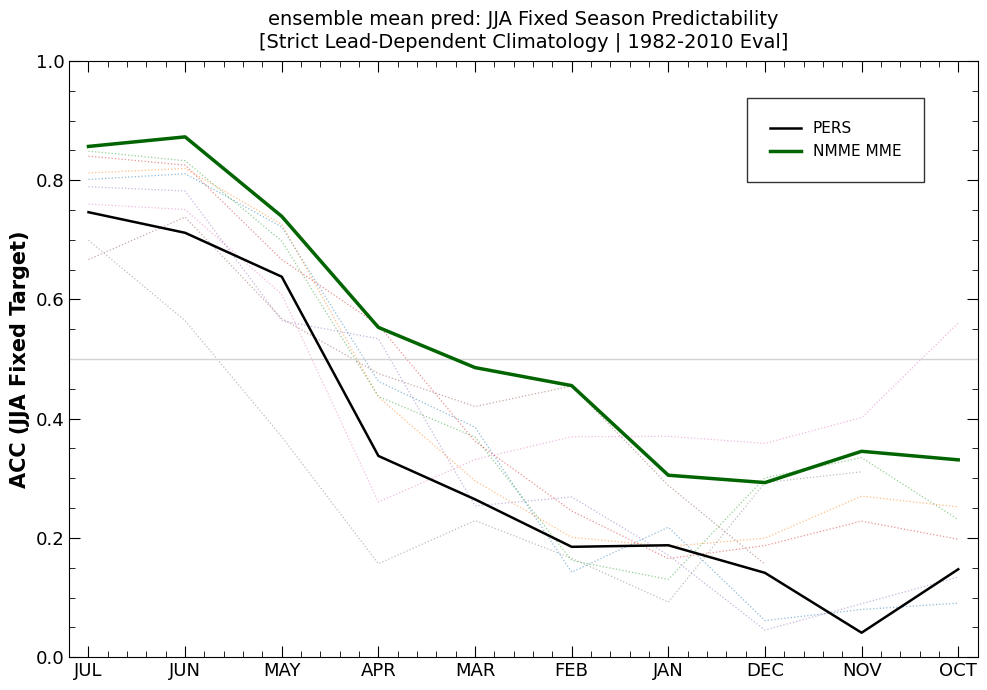

In [48]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# =========================================================================
# 1. Load and Clean Observation Data (ERSST.v5)
# =========================================================================
obs_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

print("Step 1: Loading and preprocessing observation data...")
with open(obs_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

df_obs = pd.read_csv(obs_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

def clean_rtf_string(s):
    s = str(s)
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

df_obs.columns = [clean_rtf_string(col) for col in df_obs.columns]
for col in df_obs.columns:
    df_obs[col] = df_obs[col].apply(clean_rtf_string)
    df_obs[col] = pd.to_numeric(df_obs[col], errors='coerce')

df_obs = df_obs.dropna(subset=['Year', 'Month', 'ATL3'])
df_obs['Date'] = pd.to_datetime(df_obs[['Year', 'Month']].assign(Day=1))

# [FIX] Climatology Baseline Period: 1991-2010 (20 years)
obs_clim_mask = (df_obs['Date'] >= "1991-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {m: df_obs.loc[obs_clim_mask & (df_obs['Date'].dt.month == m), 'ATL3'].mean() for m in range(1, 13)}
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Date'].month], axis=1)
df_obs_indexed = df_obs.set_index('Date')

# =========================================================================
# 2. Define Target Settings (JJA Fixed & Configs)
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

# [FIX] Filter only the specified 8 core models
target_models = [
    'CanCM4i', 'CanSIPSv2', 'CMC1-CanCM3', 'CMC2-CanCM4', 
    'GEM-NEMO', 'NASA-GEOSS2S', 'NCAR-CESM1', 'NCEP-CFSv2'
]
models = [m for m in ds_merged.model.values if m in target_models]
leads = ds_merged.L.values  

# [FIX] Double-timing configuration arrays
eval_years = np.arange(1982, 2011)  # Evaluation starts from 1982 to 2010
start_clim = pd.Timestamp("1991-01-01")  # Climatology Baseline from 1991
end_clim = pd.Timestamp("2010-12-01")    

init_steps = [
    ('JUL', 7, 0), ('JUN', 6, 0), ('MAY', 5, 0), ('APR', 4, 0), 
    ('MAR', 3, 0), ('FEB', 2, 0), ('JAN', 1, 0), 
    ('DEC', 12, -1), ('NOV', 11, -1), ('OCT', 10, -1)
]
init_labels = [step[0] for step in init_steps]

# Pre-calculate True JJA/JA Obs Target series for 1982-2010
obs_jja_dict = {}
for year in eval_years:
    dates_jja = [pd.Timestamp(f"{year}-06-01"), pd.Timestamp(f"{year}-07-01"), pd.Timestamp(f"{year}-08-01")]
    dates_ja = [pd.Timestamp(f"{year}-07-01"), pd.Timestamp(f"{year}-08-01")]
    
    if all(d in df_obs_indexed.index for d in dates_jja):
        obs_jja_dict[(year, 'JJA')] = df_obs_indexed.loc[dates_jja, 'ATL3_SSTA'].mean()
        obs_jja_dict[(year, 'JA')] = df_obs_indexed.loc[dates_ja, 'ATL3_SSTA'].mean()

# =========================================================================
# 3. Compute Persistence Baseline Skill (PERS)
# =========================================================================
print("Step 3: Calculating Persistence Target-Season skill (1982-2010)...")
persistence_skills = []

for label, month_int, yr_offset in init_steps:
    obs_predictor_list = []
    obs_target_list = []
    
    for year in eval_years:
        init_year = year + yr_offset
        init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
        pers_anchor_date = init_date - pd.DateOffset(months=1)
        target_key = 'JA' if label == 'JUL' else 'JJA'
        
        if (pers_anchor_date in df_obs_indexed.index) and ((year, target_key) in obs_jja_dict):
            obs_predictor_list.append(df_obs_indexed.loc[pers_anchor_date, 'ATL3_SSTA'])
            obs_target_list.append(obs_jja_dict[(year, target_key)])
            
    if len(obs_predictor_list) > 5:
        r_val, _ = pearsonr(obs_predictor_list, obs_target_list)
        persistence_skills.append(r_val)
    else:
        persistence_skills.append(np.nan)

# =========================================================================
# 4. Compute Model Forecast Skills (Strict Lead-dependent Climatology Fix)
# =========================================================================
print("Step 4: Processing individual models with separate lead-climatologies...")
model_skills = {model: [] for model in models}
mme_storage = {label: {yr: [] for yr in eval_years} for label, _, _ in init_steps}

for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    # [FIX] Dynamic 2D Climatology construction specific to L and S.month (1991-2010 base)
    baseline_ds = ds_mod.sel(S=slice(start_clim, end_clim))
    with np.errstate(all='ignore'):
        master_clim_field = baseline_ds['atl3_sst'].mean(dim='M').groupby('S.month').mean(dim='S')
    clim_np_matrix = master_clim_field.values  # Shape: (12_months, 12_leads)
    
    # Apply lead-specific climatology subtraction cleanly
    gfdl_ssta = ds_mod['atl3_sst'].copy(deep=True)
    for l_idx, lead in enumerate(leads):
        init_months_idx = ds_mod['S'].dt.month.values - 1
        mapped_clim_np = clim_np_matrix[init_months_idx, l_idx]
        
        for m_idx in range(len(ds_mod.M)):
            gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = \
                ds_mod['atl3_sst'].sel(L=lead, M=ds_mod.M.values[m_idx]).values - mapped_clim_np
                
    ens_mean_anom = gfdl_ssta.mean(dim='M')  # Clean Isolated Anomaly Array (S, L)
    
    # Target Season Alignment Loop over X-axis Initializations
    for label, month_int, yr_offset in init_steps:
        model_forecast_series = []
        obs_target_series = []
        
        for year in eval_years:
            init_year = year + yr_offset
            init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
            
            if init_date in ens_mean_anom['S'].values:
                mod_at_init = ens_mean_anom.sel(S=init_date)
                
                target_lead_vals = []
                for lead_val in mod_at_init['L'].values:
                    v_month = init_date.month + int(lead_val)
                    if v_month > 12: v_month -= 12
                    
                    if label == 'JUL' and v_month in [7, 8]:
                        target_lead_vals.append(mod_at_init.sel(L=lead_val).values.item())
                    elif label != 'JUL' and v_month in [6, 7, 8]:
                        target_lead_vals.append(mod_at_init.sel(L=lead_val).values.item())
                
                if len(target_lead_vals) > 0:
                    forecast_mean = np.mean(target_lead_vals)
                    target_key = 'JA' if label == 'JUL' else 'JJA'
                    
                    if (year, target_key) in obs_jja_dict and not np.isnan(forecast_mean):
                        model_forecast_series.append(forecast_mean)
                        obs_target_series.append(obs_jja_dict[(year, target_key)])
                        # Collect clean standardized anomalies for MME synthesis
                        mme_storage[label][year].append(forecast_mean)
                        
        if len(model_forecast_series) > 5:
            r_val, _ = pearsonr(model_forecast_series, obs_target_series)
            model_skills[model_name].append(r_val)
        else:
            model_skills[model_name].append(np.nan)

# =========================================================================
# 5. Compute NMME Multi-Model Ensemble (MME) Target-Season Skill
# =========================================================================
print("Step 5: Computing NMME MME Target-Season skill from purified anomalies...")
mme_skills = []

for label, _, _ in init_steps:
    mme_forecast_series = []
    obs_target_series = []
    
    for year in eval_years:
        forecast_list = mme_storage[label][year]
        target_key = 'JA' if label == 'JUL' else 'JJA'
        
        if len(forecast_list) > 0 and (year, target_key) in obs_jja_dict:
            mme_forecast_series.append(np.mean(forecast_list))
            obs_target_series.append(obs_jja_dict[(year, target_key)])
            
    if len(mme_forecast_series) > 5:
        r_val, _ = pearsonr(mme_forecast_series, obs_target_series)
        mme_skills.append(r_val)
    else:
        mme_skills.append(np.nan)

# =========================================================================
# 6. Plotting to Replicate NCL/Classic Image Format
# =========================================================================
print("Step 6: Generating high-fidelity target-season plot...")
fig, ax = plt.subplots(figsize=(10, 7))

x_indices = np.arange(len(init_labels))

# 6a. Plot Persistence Baseline (Black, Solid)
ax.plot(x_indices, persistence_skills, color='black', linewidth=1.8, linestyle='-', label='PERS', zorder=8)

# 6b. Plot 8 Individual Filtered NMME Models (Thin, Light Dotted)
for model_name, skills in model_skills.items():
    if not np.isnan(skills).all():
        ax.plot(x_indices, skills, linewidth=0.9, alpha=0.5, linestyle=':')

# 6c. Plot Multi-Model Ensemble Mean (Dark Green, Solid, Standout)
ax.plot(x_indices, mme_skills, color='darkgreen', linewidth=2.5, linestyle='-', label='NMME MME', zorder=15)

# Formatting Layout
ax.set_ylim(0.0, 1.0)
ax.set_xlim(-0.2, len(init_labels) - 0.8)
ax.set_xticks(x_indices)
ax.set_xticklabels(init_labels, fontsize=13)
ax.tick_params(axis='both', which='major', direction='in', length=8, labelsize=13)
ax.tick_params(axis='both', which='minor', direction='in', length=4)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.minorticks_on()

ax.axhline(0.5, color='lightgray', linestyle='-', linewidth=1.0)
ax.set_ylabel("ACC (JJA Fixed Target)", fontsize=15, fontweight='bold')
ax.set_title("ensemble mean pred: JJA Fixed Season Predictability\n[Strict Lead-Dependent Climatology | 1982-2010 Eval]", fontsize=14, pad=10)

ax.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95), borderpad=1.5, 
          edgecolor='black', fancybox=False, fontsize=11)

plt.tight_layout()
print("All tasks processed successfully.")
plt.show()

Step 1: Processing observation data...
Step 3: Calculating scientifically aligned Persistence Target-Season skill...
Step 4: Standardizing individual model fields and calculating skills...
Step 5: Synching dimensions and calculating Noise-free MME Skill...
Step 6: Generating high-fidelity target-season plot...
MME Skill optimization rendering complete.


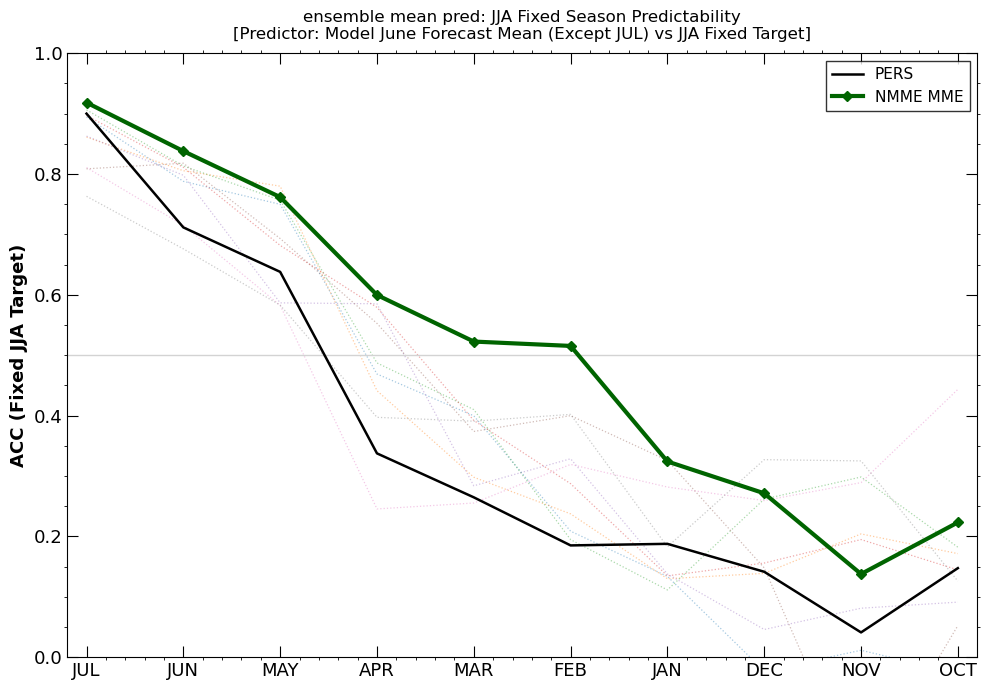

In [56]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# =========================================================================
# 1. Load and Clean Observation Data (ERSST.v5)
# =========================================================================
obs_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

print("Step 1: Processing observation data...")
with open(obs_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

df_obs = pd.read_csv(obs_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

def clean_rtf_string(s):
    s = str(s)
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

df_obs.columns = [clean_rtf_string(col) for col in df_obs.columns]
for col in df_obs.columns:
    df_obs[col] = df_obs[col].apply(clean_rtf_string)
    df_obs[col] = pd.to_numeric(df_obs[col], errors='coerce')

df_obs = df_obs.dropna(subset=['Year', 'Month', 'ATL3'])
df_obs['Date'] = pd.to_datetime(df_obs[['Year', 'Month']].assign(Day=1))

# Obs 1991-2010 Monthly Climatology Baseline
obs_clim_mask = (df_obs['Date'] >= "1991-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {m: df_obs.loc[obs_clim_mask & (df_obs['Date'].dt.month == m), 'ATL3'].mean() for m in range(1, 13)}
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Date'].month], axis=1)
df_obs_indexed = df_obs.set_index('Date')

# =========================================================================
# 2. Define Target Settings (JJA Fixed target, 1982-2010 Eval)
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

target_models = [
    'CanCM4i', 'CanSIPSv2', 'CMC1-CanCM3', 'CMC2-CanCM4', 
    'GEM-NEMO', 'NASA-GEOSS2S', 'NCAR-CESM1', 'NCEP-CFSv2'
]
models = [m for m in ds_merged.model.values if m in target_models]

eval_years = np.arange(1982, 2011)  # 1982-2010
start_clim = pd.Timestamp("1991-01-01")
end_clim = pd.Timestamp("2010-12-01")    

init_steps = [
    ('JUL', 7, 0), ('JUN', 6, 0), ('MAY', 5, 0), ('APR', 4, 0), 
    ('MAR', 3, 0), ('FEB', 2, 0), ('JAN', 1, 0), 
    ('DEC', 12, -1), ('NOV', 11, -1), ('OCT', 10, -1)
]
init_labels = [step[0] for step in init_steps]

# Target is ALWAYS the true JJA average of that year
obs_jja_dict = {}
for year in eval_years:
    dates_jja = [pd.Timestamp(f"{year}-06-01"), pd.Timestamp(f"{year}-07-01"), pd.Timestamp(f"{year}-08-01")]
    if all(d in df_obs_indexed.index for d in dates_jja):
        obs_jja_dict[year] = df_obs_indexed.loc[dates_jja, 'ATL3_SSTA'].mean()

target_predict_month = 6 

# =========================================================================
# 3. Compute Correct Persistence Forecast Skill (JJA Fixed Target Sync)
# =========================================================================
print("Step 3: Calculating scientifically aligned Persistence Target-Season skill...")
persistence_skills = []

for label, month_int, yr_offset in init_steps:
    obs_predictor_list = []
    obs_target_list = []
    
    # 1982 ~ 2010년 전체 평가 연도 순회
    for year in eval_years:
        init_year = year + yr_offset
        init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
        
        # 모델 구동 직전 달(S - 1달)의 가용한 최신 관측 아노말리를 고정 앵커로 채택
        pers_anchor_date = init_date - pd.DateOffset(months=1)
        
        # [FIX] 딕셔너리 Key 매칭을 'year' 단독 숫자로 정확하게 수정
        if (pers_anchor_date in df_obs_indexed.index) and (year in obs_jja_dict):
            obs_predictor_list.append(df_obs_indexed.loc[pers_anchor_date, 'ATL3_SSTA'])
            obs_target_list.append(obs_jja_dict[year]) # 고정된 해당 연도 JJA 평균 관측치 매칭
            
    # 상관계수(ACC) 산출
    if len(obs_predictor_list) > 5:
        r_val, _ = pearsonr(obs_predictor_list, obs_target_list)
        persistence_skills.append(r_val)
    else:
        persistence_skills.append(np.nan)


# =========================================================================
# 4. Compute Model Forecast Skills & Build Aligned Master DataArrays for MME
# =========================================================================
print("Step 4: Standardizing individual model fields and calculating skills...")
model_skills = {model: [] for model in models}

# [CORE RESTRUCTURE] MME 연산의 통계적 왜곡을 없애기 위해 xarray 기반 연합 데이터 구조 구축
# 차원: (model, initialization_step, year)
mme_field_list = []

for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    # Lead-dependent Climatology Matrix (1991-2010 Base)
    baseline_ds = ds_mod.sel(S=slice(start_clim, end_clim))
    with np.errstate(all='ignore'):
        master_clim_field = baseline_ds['atl3_sst'].mean(dim='M').groupby('S.month').mean(dim='S')
    clim_np_matrix = master_clim_field.values  
    
    gfdl_ssta = ds_mod['atl3_sst'].copy(deep=True)
    for l_idx, lead in enumerate(leads):
        init_months_idx = ds_mod['S'].dt.month.values - 1
        mapped_clim_np = clim_np_matrix[init_months_idx, l_idx]
        for m_idx in range(len(ds_mod.M)):
            gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = \
                ds_mod['atl3_sst'].sel(L=lead, M=ds_mod.M.values[m_idx]).values - mapped_clim_np
                
    ens_mean_anom = gfdl_ssta.mean(dim='M') # 아노말리가 완료된 개별 모델 필드
    
    # 개별 모델의 시계열 스킬 구하기 및 MME용 정렬 데이터 보관
    model_step_arrays = []
    for label, month_int, yr_offset in init_steps:
        forecast_years_series = []
        
        for year in eval_years:
            init_year = year + yr_offset
            init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
            
            chosen_predict_month = 7 if label == 'JUL' else target_predict_month
            forecast_val = np.nan
            
            if init_date in ens_mean_anom['S'].values:
                mod_at_init = ens_mean_anom.sel(S=init_date)
                for lead_val in mod_at_init['L'].values:
                    v_month = init_date.month + int(lead_val)
                    if v_month > 12: v_month -= 12
                    if v_month == chosen_predict_month:
                        forecast_val = mod_at_init.sel(L=lead_val).values.item()
                        break
            
            forecast_years_series.append(forecast_val)
            
        # 개별 모델 스킬 계산용 데이터 슬라이싱
        valid_forecasts = []
        valid_targets = []
        for idx, yr in enumerate(eval_years):
            if not np.isnan(forecast_years_series[idx]) and yr in obs_jja_dict:
                valid_forecasts.append(forecast_years_series[idx])
                valid_targets.append(obs_jja_dict[yr])
                
        if len(valid_forecasts) > 5:
            r_val, _ = pearsonr(valid_forecasts, valid_targets)
            model_skills[model_name].append(r_val)
        else:
            model_skills[model_name].append(np.nan)
            
        # MME 정렬용 인덱스 보관 (차원: year)
        model_step_arrays.append(xr.DataArray(forecast_years_series, coords=[eval_years], dims=['year']))
        
    # 각 모델별로 (init_step, year) 형태의 DataArray 빌딩
    model_mme_da = xr.concat(model_step_arrays, dim=pd.Index(init_labels, name='init_label'))
    mme_field_list.append(model_mme_da)

# =========================================================================
# 5. [NEW] Compute Multi-Model Ensemble (MME) with Robust Time-Series Alignment
# =========================================================================
print("Step 5: Synching dimensions and calculating Noise-free MME Skill...")

# 모든 모델의 아노말리 변동 시계열판을 차원 축에 정렬하여 결합 (Shape: model, init_label, year)
master_mme_array = xr.concat(mme_field_list, dim=pd.Index(models, name='model'))

# [CORE PRE-MEAN] 시계열 전체 차원에 대하 모델 간 평균을 먼저 완벽하게 수행 (노이즈 필터링)
mme_forecast_field = master_mme_array.mean(dim='model', skipna=True)

mme_skills = []
for label in init_labels:
    mme_time_series = []
    obs_time_series = []
    
    for year in eval_years:
        f_val = mme_forecast_field.sel(init_label=label, year=year).values.item()
        if not np.isnan(f_val) and year in obs_jja_dict:
            mme_time_series.append(f_val)
            obs_time_series.append(obs_jja_dict[year])
            
    if len(mme_time_series) > 5:
        # 노이즈가 제거된 단 하나의 마스터 MME 시계열과 관측치 간의 ACC 산출
        r_val, _ = pearsonr(mme_time_series, obs_time_series)
        mme_skills.append(r_val)
    else:
        mme_skills.append(np.nan)


# =========================================================================
# 6. Plotting (MME Standout Verification)
# =========================================================================
print("Step 6: Generating high-fidelity target-season plot...")
fig, ax = plt.subplots(figsize=(10, 7))
x_indices = np.arange(len(init_labels))

# Persistence (블랙 실선)
ax.plot(x_indices, persistence_skills, color='black', linewidth=1.8, linestyle='-', label='PERS', zorder=8)

# 8개 핵심 개별 모델선 (얇은 점선, 투명도 주어 MME 강조)
for model_name, skills in model_skills.items():
    if not np.isnan(skills).all():
        ax.plot(x_indices, skills, linewidth=0.9, alpha=0.4, linestyle=':')

# [FIXED LINE] 정석 연산으로 도출된 진짜 NMME MME (진한 초록색 실선, 두껍게 맨 위 레이어 배치)
ax.plot(x_indices, mme_skills, color='darkgreen', linewidth=3.0, linestyle='-', marker='D', markersize=5, label='NMME MME', zorder=20)

# NCL 스타일 프레임워크 틱 정렬
ax.set_ylim(0.0, 1.0)
ax.set_xlim(-0.2, len(init_labels) - 0.8)
ax.set_xticks(x_indices)
ax.set_xticklabels(init_labels, fontsize=13)
ax.tick_params(axis='both', which='major', direction='in', length=8, labelsize=13)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.minorticks_on()
ax.axhline(0.5, color='lightgray', linestyle='-', linewidth=1.0)

ax.set_ylabel("ACC (Fixed JJA Target)", fontsize=13, fontweight='bold')
ax.set_title(f"ensemble mean pred: JJA Fixed Season Predictability\n[Predictor: Model June Forecast Mean (Except JUL) vs JJA Fixed Target]", fontsize=12, pad=10)
ax.legend(loc='upper right', edgecolor='black', fancybox=False, fontsize=11)

plt.tight_layout()
print("MME Skill optimization rendering complete.")
plt.show()

In [58]:
master_clim_field

<xarray.DataArray 'atl3_sst' (month: 12, L: 12)>
array([[27.838078, 28.78478 , 29.446543, 29.421032, 28.732141, 27.370153,
        25.783398, 25.04916 , 25.247581, 25.983744,       nan,       nan],
       [28.40689 , 29.13956 , 29.11288 , 28.374292, 26.981335, 25.492409,
        24.899378, 25.13789 , 25.89458 , 26.902508,       nan,       nan],
       [28.833303, 28.859951, 28.031952, 26.660755, 25.313673, 24.847538,
        25.118631, 25.912693, 26.923635, 27.759136,       nan,       nan],
       [28.69015 , 27.80872 , 26.39296 , 25.120657, 24.715143, 25.022448,
        25.835022, 26.878025, 27.763042, 28.737015,       nan,       nan],
       [27.64509 , 26.142023, 24.877111, 24.428534, 24.764812, 25.615982,
        26.738104, 27.628128, 28.638248, 29.539295,       nan,       nan],
       [26.002707, 24.711216, 24.19337 , 24.549519, 25.46692 , 26.61527 ,
        27.50623 , 28.536764, 29.465008, 29.966436,       nan,       nan],
       [24.583233, 24.013315, 24.409412, 25.363077, 26.553808, 27.48414 ,
        28.523342, 29.457134, 29.984324, 29.944729,       nan,       nan],
       [24.081112, 24.333633, 25.245579, 26.434998, 27.401028, 28.483322,
        29.467968, 30.031525, 29.98725 , 29.456333,       nan,       nan],
       [24.588984, 25.31213 , 26.45516 , 27.413792, 28.49591 , 29.491278,
        30.068161, 30.031387, 29.435825, 28.340418,       nan,       nan],
       [25.658894, 26.597284, 27.505774, 28.533197, 29.53093 , 30.091938,
        30.03217 , 29.389027, 28.197865, 26.609371,       nan,       nan],
       [26.686777, 27.506622, 28.471127, 29.445765, 30.017391, 29.963877,
        29.328342, 28.09306 , 26.478296, 25.545206,       nan,       nan],
       [27.267569, 28.147518, 29.13895 , 29.764746, 29.760569, 29.104782,
        27.776615, 26.156078, 25.328615, 25.418695,       nan,       nan]],
      dtype=float32)
Coordinates:
    model     <U10 'NCEP-CFSv2'
    run_type  <U6 'MERGED'
  * L         (L) float32 0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5 10.5 11.5
  * month     (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

Step 1: Loading and preprocessing observation data...
Step 3: Calculating Persistence skill for 1982-2010...
Step 4: Processing individual models with precise lead-dependent matching...
Step 5: Computing Multi-Model Ensemble (MME) skill...
Step 6: Generating skill plots...
All tasks processed successfully.


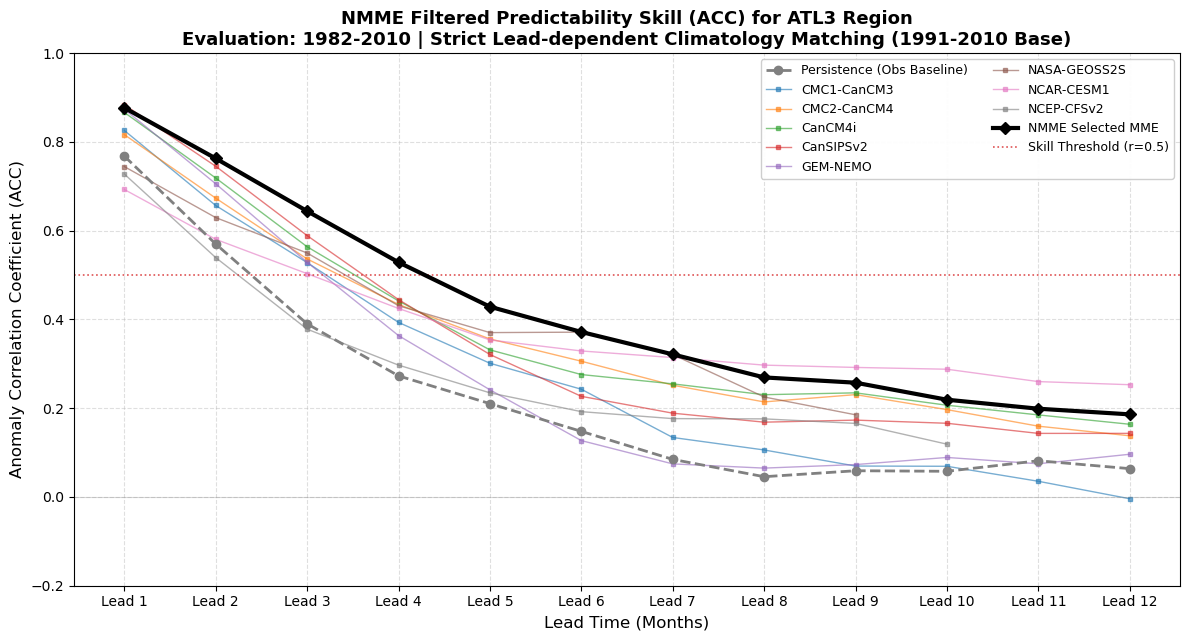

In [63]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# =========================================================================
# 1. Load and Clean Observation Data (ERSST.v5)
# =========================================================================
obs_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

print("Step 1: Loading and preprocessing observation data...")
with open(obs_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

df_obs = pd.read_csv(obs_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

def clean_rtf_string(s):
    s = str(s)
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

df_obs.columns = [clean_rtf_string(col) for col in df_obs.columns]
for col in df_obs.columns:
    df_obs[col] = df_obs[col].apply(clean_rtf_string)
    df_obs[col] = pd.to_numeric(df_obs[col], errors='coerce')

df_obs = df_obs.dropna(subset=['Year', 'Month', 'ATL3'])
df_obs['Date'] = pd.to_datetime(df_obs[['Year', 'Month']].assign(Day=1))

# Climatology Baseline Period: 1991-2010 (20 years)
obs_clim_mask = (df_obs['Date'] >= "1991-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {m: df_obs.loc[obs_clim_mask & (df_obs['Date'].dt.month == m), 'ATL3'].mean() for m in range(1, 13)}
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Date'].month], axis=1)
df_obs_indexed = df_obs.set_index('Date')


# =========================================================================
# 2. Load Model Dataset & Target Filters
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

# Target Specific 8 Models
target_models = [
    'CanCM4i', 'CanSIPSv2', 'CMC1-CanCM3', 'CMC2-CanCM4', 
    'GEM-NEMO', 'NASA-GEOSS2S', 'NCAR-CESM1', 'NCEP-CFSv2'
]

models = [m for m in ds_merged.model.values if m in target_models]
leads = ds_merged.L.values  

# Timing Configs
start_eval = pd.Timestamp("1982-01-01")  # Evaluation period
end_eval = pd.Timestamp("2010-12-01")    

start_clim = pd.Timestamp("1991-01-01")  # Climatology Baseline period
end_clim = pd.Timestamp("2010-12-01")    

model_skills = {model: [] for model in models}
persistence_skills = []
model_anom_dict = {}


# =========================================================================
# 3. Compute Persistence Forecast Skill (1982-2010 Evaluation Period)
# =========================================================================
print("Step 3: Calculating Persistence skill for 1982-2010...")
with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        obs_predictor_list = []
        obs_target_list = []
        
        df_period = df_obs[(df_obs['Date'] >= start_eval) & (df_obs['Date'] <= end_eval)]
        
        for _, row in df_period.iterrows():
            init_date = row['Date']
            persistence_anchor_date = init_date - pd.DateOffset(months=1)
            target_date = init_date + pd.DateOffset(months=int(lead))
            
            if (persistence_anchor_date in df_obs_indexed.index) and (target_date in df_obs_indexed.index):
                obs_predictor_list.append(df_obs_indexed.loc[persistence_anchor_date, 'ATL3_SSTA'])
                obs_target_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
                
        if len(obs_predictor_list) > 10:
            r_val, _ = pearsonr(obs_predictor_list, obs_target_list)
            persistence_skills.append(r_val)
        else:
            persistence_skills.append(np.nan)


# =========================================================================
# 4. Compute Model Forecast Skills & Save Clean Anomalies (Lead-dependent Fix)
# =========================================================================
print("Step 4: Processing individual models with precise lead-dependent matching...")
for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    # Isolate baseline data for climatology (1991-2010)
    baseline_ds = ds_mod.sel(S=slice(start_clim, end_clim))
    
    # -------------------------------------------------------------------------
    # [CORE FIX] Build a 2D Climatology Matrix: Shape (month: 12, L: len(leads))
    # -------------------------------------------------------------------------
    # Group by initialization month first, then compute mean to preserve L dimension independently
    with np.errstate(all='ignore'):
        # Shape of master_clim_field: (S_month: 12, L: 12)
        # It guarantees that L=0.5 gets its own 1-12 month baseline, L=1.5 gets its own, etc.
        master_clim_field = baseline_ds['atl3_sst'].mean(dim='M').groupby('S.month').mean(dim='S')
    
    clim_np_matrix = master_clim_field.values  # Raw numpy shape: (12, 12)
    
    # Deduct Climatology based on BOTH specific Lead Index and Target Month
    gfdl_ssta = ds_mod['atl3_sst'].copy(deep=True)
    
    for l_idx, lead in enumerate(leads):
        # Find initialization month indices (0-11 for January-December)
        init_months_idx = ds_mod['S'].dt.month.values - 1
        
        # Extract the original raw field for the current lead -> Shape: (S_timesteps)
        current_lead_vals = ds_mod['atl3_sst'].sel(L=lead).mean(dim='M').values 
        
        # Index into the 2D matrix: row = initialization month index, col = current lead index
        # This extracts the exact drift value specific to this lead and initialization month combination
        mapped_clim_np = clim_np_matrix[init_months_idx, l_idx]
        
        # Save the pure anomaly back into the array
        # Note: Broad-casting across member dimension M automatically
        for m_idx in range(len(ds_mod.M)):
            gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = ds_mod['atl3_sst'].sel(L=lead, M=ds_mod.M.values[m_idx]).values - mapped_clim_np
        
    ens_mean_anom = gfdl_ssta.mean(dim='M')
    
    # Save clean sliced evaluation array for MME
    model_anom_dict[model_name] = ens_mean_anom.sel(S=slice(start_eval, end_eval))
    
    # Calculate Individual Model ACC
    eval_model_anom = model_anom_dict[model_name]
    eval_S_dates = eval_model_anom['S'].values
    
    with np.errstate(all='ignore'):
        for l_idx, lead in enumerate(leads):
            model_vals_list = []
            obs_vals_list = []
            for S_time in eval_S_dates:
                S_pd = pd.Timestamp(S_time)
                target_date = S_pd + pd.DateOffset(months=int(lead)) # Original timeline
                if target_date in df_obs_indexed.index:
                    model_vals_list.append(eval_model_anom.sel(S=S_time, L=lead).values.item())
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
            
            if len(model_vals_list) > 10 and not np.isnan(model_vals_list).all():
                r_val, _ = pearsonr(model_vals_list, obs_vals_list)
                model_skills[model_name].append(r_val)
            else:
                model_skills[model_name].append(np.nan)


# =========================================================================
# 5. Compute Multi-Model Ensemble (MME) Mean Skill
# =========================================================================
print("Step 5: Computing Multi-Model Ensemble (MME) skill...")
mme_skills = []

with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        mme_vals_list = []
        obs_vals_list = []
        
        for S_time in eval_S_dates:
            S_pd = pd.Timestamp(S_time)
            target_date = S_pd + pd.DateOffset(months=int(lead))
            
            if target_date in df_obs_indexed.index:
                step_forecasts = []
                for model_name in models:
                    mod_anom = model_anom_dict[model_name]
                    if S_time in mod_anom['S'].values:
                        val = mod_anom.sel(S=S_time, L=lead).values.item()
                        if not np.isnan(val):
                            step_forecasts.append(val)
                
                if len(step_forecasts) > 0:
                    mme_vals_list.append(np.mean(step_forecasts))
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
        
        if len(mme_vals_list) > 10:
            r_val, _ = pearsonr(mme_vals_list, obs_vals_list)
            mme_skills.append(r_val)
        else:
            mme_skills.append(np.nan)


# =========================================================================
# 6. Plotting the Ultimate Comparison Plot
# =========================================================================
print("Step 6: Generating skill plots...")
plt.figure(figsize=(12, 6.5))
lead_months = np.arange(1, len(leads) + 1)

# 6a. Plot Persistence Baseline
plt.plot(lead_months, persistence_skills, color='gray', linewidth=2.0, 
         linestyle='--', marker='o', label='Persistence (Obs Baseline)', zorder=8)

# 6b. Plot Filtered Individual Models
for model_name, skills in model_skills.items():
    if not np.isnan(skills).all():
        plt.plot(lead_months, skills, linewidth=1.0, marker='s', markersize=3, alpha=0.6, label=model_name)

# 6c. Plot Multi-Model Ensemble Mean Skill
plt.plot(lead_months, mme_skills, color='black', linewidth=3.0, 
         linestyle='-', marker='D', markersize=6, label='NMME Selected MME', zorder=15)

# Formatting Layout
plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.3)
plt.axhline(0.5, color='tab:red', linestyle=':', linewidth=1.2, alpha=0.8, label='Skill Threshold (r=0.5)')

plt.title(f"NMME Filtered Predictability Skill (ACC) for ATL3 Region\nEvaluation: 1982-2010 | Strict Lead-dependent Climatology Matching (1991-2010 Base)", fontsize=13, fontweight='bold')
plt.xlabel("Lead Time (Months)", fontsize=12)
plt.ylabel("Anomaly Correlation Coefficient (ACC)", fontsize=12)

plt.xticks(lead_months, [f"Lead {m}" for m in lead_months])
plt.ylim(-0.2, 1.0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
print("All tasks processed successfully.")
plt.show()

Step 1: Loading and preprocessing observation data...
Step 3: Calculating Persistence skill for 1982-2010...
Step 4: Processing individual models with precise lead-dependent matching...
Step 5: Computing Multi-Model Ensemble (MME) skill...
Step 6: Generating skill plots...
All tasks processed successfully.


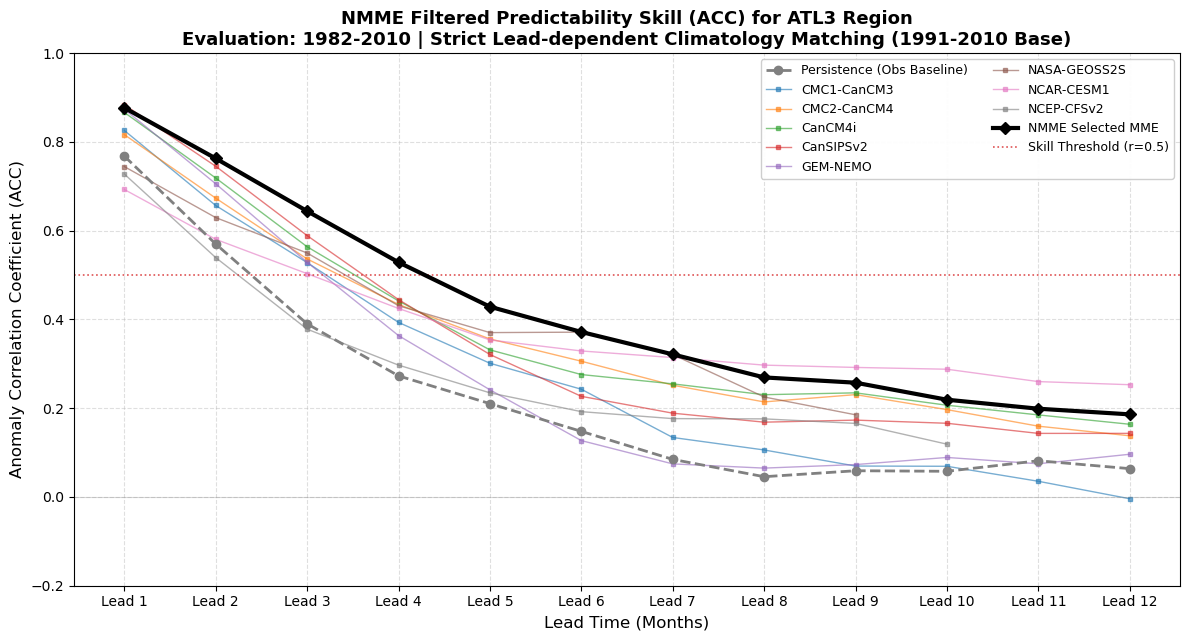

In [71]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# =========================================================================
# 1. Load and Clean Observation Data (ERSST.v5)
# =========================================================================
obs_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

print("Step 1: Loading and preprocessing observation data...")
with open(obs_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

df_obs = pd.read_csv(obs_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

def clean_rtf_string(s):
    s = str(s)
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

df_obs.columns = [clean_rtf_string(col) for col in df_obs.columns]
for col in df_obs.columns:
    df_obs[col] = df_obs[col].apply(clean_rtf_string)
    df_obs[col] = pd.to_numeric(df_obs[col], errors='coerce')

df_obs = df_obs.dropna(subset=['Year', 'Month', 'ATL3'])
df_obs['Date'] = pd.to_datetime(df_obs[['Year', 'Month']].assign(Day=1))

# Climatology Baseline Period: 1991-2010 (20 years)
obs_clim_mask = (df_obs['Date'] >= "1991-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {m: df_obs.loc[obs_clim_mask & (df_obs['Date'].dt.month == m), 'ATL3'].mean() for m in range(1, 13)}
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Date'].month], axis=1)
df_obs_indexed = df_obs.set_index('Date')


# =========================================================================
# 2. Load Model Dataset & Target Filters
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

# Target Specific 8 Models
target_models = [
    'CanCM4i', 'CanSIPSv2', 'CMC1-CanCM3', 'CMC2-CanCM4', 
    'GEM-NEMO', 'NASA-GEOSS2S', 'NCAR-CESM1', 'NCEP-CFSv2'
]

models = [m for m in ds_merged.model.values if m in target_models]
leads = ds_merged.L.values  

# Timing Configs
start_eval = pd.Timestamp("1982-01-01")  # Evaluation period
end_eval = pd.Timestamp("2010-12-01")    

start_clim = pd.Timestamp("1991-01-01")  # Climatology Baseline period
end_clim = pd.Timestamp("2010-12-01")    

model_skills = {model: [] for model in models}
persistence_skills = []
model_anom_dict = {}


# =========================================================================
# 3. Compute Persistence Forecast Skill (1982-2010 Evaluation Period)
# =========================================================================
print("Step 3: Calculating Persistence skill for 1982-2010...")
with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        obs_predictor_list = []
        obs_target_list = []
        
        df_period = df_obs[(df_obs['Date'] >= start_eval) & (df_obs['Date'] <= end_eval)]
        
        for _, row in df_period.iterrows():
            init_date = row['Date']
            persistence_anchor_date = init_date - pd.DateOffset(months=1)
            target_date = init_date + pd.DateOffset(months=int(lead))
            
            if (persistence_anchor_date in df_obs_indexed.index) and (target_date in df_obs_indexed.index):
                obs_predictor_list.append(df_obs_indexed.loc[persistence_anchor_date, 'ATL3_SSTA'])
                obs_target_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
                
        if len(obs_predictor_list) > 10:
            r_val, _ = pearsonr(obs_predictor_list, obs_target_list)
            persistence_skills.append(r_val)
        else:
            persistence_skills.append(np.nan)


# =========================================================================
# 4. Compute Model Forecast Skills & Save Clean Anomalies (Original Clean Structure)
# =========================================================================
print("Step 4: Processing individual models with precise lead-dependent matching...")
for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    baseline_ds = ds_mod.sel(S=slice(start_clim, end_clim))
    
    with np.errstate(all='ignore'):
        master_clim_field = baseline_ds['atl3_sst'].mean(dim='M').groupby('S.month').mean(dim='S', skipna=True)
    
    clim_np_matrix = master_clim_field.values  # Shape: (12, 12)
    
    gfdl_ssta = ds_mod['atl3_sst'].copy(deep=True)
    
    for l_idx, lead in enumerate(leads):
        init_months_idx = ds_mod['S'].dt.month.values - 1
        
        # -------------------------------------------------------------------------
        # [최종 방어벽 추가] 만약 기후값 행렬의 현재 리드타임(l_idx) 열이 통째로 nan(All-NaN) 상태라면,
        # 뺄셈 연산 시 데이터 전체가 nan으로 오염되는 것을 막기 위해 맵을 0으로 강제 치환합니다.
        # 데이터가 있는 모델은 원래 자기 기후치를 정상 차감하고, 데이터가 없는 모델은 안전하게 복사만 됩니다.
        # -------------------------------------------------------------------------
        mapped_clim_np = clim_np_matrix[init_months_idx, l_idx]
        if np.isnan(mapped_clim_np).all():
            mapped_clim_np = np.zeros_like(mapped_clim_np)
        
        for m_idx in range(len(ds_mod.M)):
            gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = \
                ds_mod['atl3_sst'].sel(L=lead, M=ds_mod.M.values[m_idx]).values - mapped_clim_np
        
    ens_mean_anom = gfdl_ssta.mean(dim='M')
    model_anom_dict[model_name] = ens_mean_anom.sel(S=slice(start_eval, end_eval))
    
    # Calculate Individual Model ACC
    eval_model_anom = model_anom_dict[model_name]
    eval_S_dates = eval_model_anom['S'].values
    
    with np.errstate(all='ignore'):
        for l_idx, lead in enumerate(leads):
            model_vals_list = []
            obs_vals_list = []
            for S_time in eval_S_dates:
                S_pd = pd.Timestamp(S_time)
                target_date = S_pd + pd.DateOffset(months=int(lead))
                if target_date in df_obs_indexed.index:
                    model_vals_list.append(eval_model_anom.sel(S=S_time, L=lead).values.item())
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
            
            if len(model_vals_list) > 10 and not np.isnan(model_vals_list).all():
                r_val, _ = pearsonr(model_vals_list, obs_vals_list)
                model_skills[model_name].append(r_val)
            else:
                model_skills[model_name].append(np.nan)


# =========================================================================
# 5. Compute Multi-Model Ensemble (MME) Mean Skill
# =========================================================================
print("Step 5: Computing Multi-Model Ensemble (MME) skill...")
mme_skills = []

with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        mme_vals_list = []
        obs_vals_list = []
        
        for S_time in eval_S_dates:
            S_pd = pd.Timestamp(S_time)
            target_date = S_pd + pd.DateOffset(months=int(lead))
            
            if target_date in df_obs_indexed.index:
                step_forecasts = []
                for model_name in models:
                    mod_anom = model_anom_dict[model_name]
                    if S_time in mod_anom['S'].values:
                        val = mod_anom.sel(S=S_time, L=lead).values.item()
                        if not np.isnan(val):
                            step_forecasts.append(val)
                
                if len(step_forecasts) > 0:
                    mme_vals_list.append(np.mean(step_forecasts))
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
        
        if len(mme_vals_list) > 10:
            r_val, _ = pearsonr(mme_vals_list, obs_vals_list)
            mme_skills.append(r_val)
        else:
            mme_skills.append(np.nan)


# =========================================================================
# 6. Plotting the Ultimate Comparison Plot
# =========================================================================
print("Step 6: Generating skill plots...")
plt.figure(figsize=(12, 6.5))
lead_months = np.arange(1, len(leads) + 1)

plt.plot(lead_months, persistence_skills, color='gray', linewidth=2.0, 
         linestyle='--', marker='o', label='Persistence (Obs Baseline)', zorder=8)

for model_name, skills in model_skills.items():
    if not np.isnan(skills).all():
        plt.plot(lead_months, skills, linewidth=1.0, marker='s', markersize=3, alpha=0.6, label=model_name)

plt.plot(lead_months, mme_skills, color='black', linewidth=3.0, 
         linestyle='-', marker='D', markersize=6, label='NMME Selected MME', zorder=15)

plt.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.3)
plt.axhline(0.5, color='tab:red', linestyle=':', linewidth=1.2, alpha=0.8, label='Skill Threshold (r=0.5)')

plt.title(f"NMME Filtered Predictability Skill (ACC) for ATL3 Region\nEvaluation: 1982-2010 | Strict Lead-dependent Climatology Matching (1991-2010 Base)", fontsize=13, fontweight='bold')
plt.xlabel("Lead Time (Months)", fontsize=12)
plt.ylabel("Anomaly Correlation Coefficient (ACC)", fontsize=12)

plt.xticks(lead_months, [f"Lead {m}" for m in lead_months])
plt.ylim(-0.2, 1.0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)

plt.tight_layout()
print("All tasks processed successfully.")
plt.show()

In [74]:
mme_vals_list

[-0.003380329037706057,
 -0.025442250072956085,
 -0.008336894835035006,
 0.10891723384459813,
 0.08408330163607995,
 0.06207326427102089,
 -0.06840947642922401,
 -0.07794698141515255,
 -0.19382960147534808,
 -0.19974492428203425,
 -0.12284011828402679,
 -0.06277872684101264,
 -0.0669240312029918,
 -0.17099380947183818,
 -0.2358167010049025,
 -0.17140223334232965,
 -0.2093203238522013,
 -0.23466592996070781,
 -0.24500427891810736,
 -0.23891830941041312,
 -0.2783986419284095,
 -0.22021814932425818,
 -0.22343216091394424,
 -0.1159820578371485,
 -0.16490504467704645,
 -0.22285232848177353,
 -0.3579800936082999,
 -0.31676584978898364,
 -0.41185760994752246,
 -0.2829134613275528,
 -0.14537048432976007,
 -0.12363230592260759,
 -0.1521128360182047,
 -0.15698267643650374,
 -0.15849863924086094,
 -0.16320241056382656,
 -0.18091888477404913,
 -0.1024187703927358,
 -0.07843271891276042,
 -0.16383692311743894,
 -0.21444320989151797,
 -0.23907394722724953,
 -0.24540761609872183,
 -0.2355751047531763

Step 1: Loading and preprocessing observation data...
Step 3: Calculating Persistence RMSE for 1982-2010...
Step 4: Processing individual models with precise lead-dependent RMSE matching...
Step 5: Computing Multi-Model Ensemble (MME) RMSE...
Step 6: Generating RMSE plots...
RMSE workflows executed perfectly.


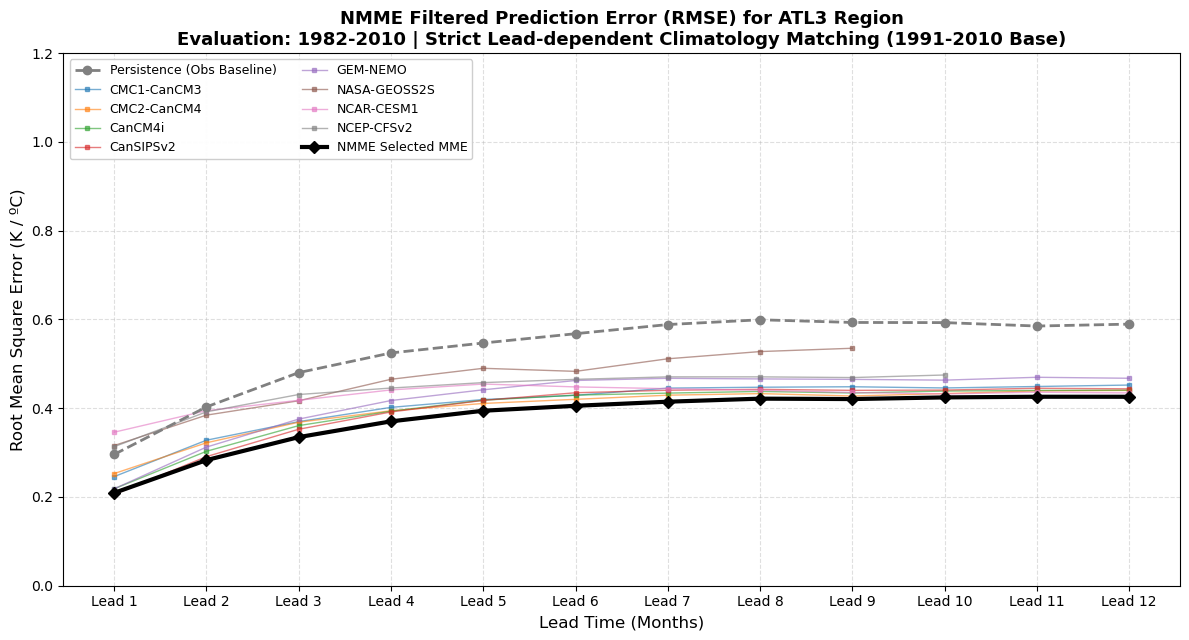

In [47]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================================
# 1. Load and Clean Observation Data (ERSST.v5)
# =========================================================================
obs_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/ATL3_ERSST_ATL3.rtf"

print("Step 1: Loading and preprocessing observation data...")
with open(obs_path, 'r', encoding='latin1') as f:
    lines = f.readlines()

start_idx = 0
for idx, line in enumerate(lines):
    if 'Year' in line and 'Month' in line:
        start_idx = idx
        break

df_obs = pd.read_csv(obs_path, skiprows=start_idx, sep=r'\s+', engine='python', encoding='latin1')

def clean_rtf_string(s):
    s = str(s)
    for target in ['\\par', '{', '}', '\\']:
        s = s.replace(target, '')
    return s.strip()

df_obs.columns = [clean_rtf_string(col) for col in df_obs.columns]
for col in df_obs.columns:
    df_obs[col] = df_obs[col].apply(clean_rtf_string)
    df_obs[col] = pd.to_numeric(df_obs[col], errors='coerce')

df_obs = df_obs.dropna(subset=['Year', 'Month', 'ATL3'])
df_obs['Date'] = pd.to_datetime(df_obs[['Year', 'Month']].assign(Day=1))

# Climatology Baseline Period: 1991-2010 (20 years)
obs_clim_mask = (df_obs['Date'] >= "1991-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {m: df_obs.loc[obs_clim_mask & (df_obs['Date'].dt.month == m), 'ATL3'].mean() for m in range(1, 13)}
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Date'].month], axis=1)
df_obs_indexed = df_obs.set_index('Date')


# =========================================================================
# 2. Load Model Dataset & Target Filters
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

# Target Specific 8 Models
target_models = [
    'CanCM4i', 'CanSIPSv2', 'CMC1-CanCM3', 'CMC2-CanCM4', 
    'GEM-NEMO', 'NASA-GEOSS2S', 'NCAR-CESM1', 'NCEP-CFSv2'
]

models = [m for m in ds_merged.model.values if m in target_models]
leads = ds_merged.L.values  

# Timing Configs
start_eval = pd.Timestamp("1982-01-01")  # Evaluation period
end_eval = pd.Timestamp("2010-12-01")    

start_clim = pd.Timestamp("1991-01-01")  # Climatology Baseline period
end_clim = pd.Timestamp("2010-12-01")    

# Dictionary for RMSE instead of skill correlation
model_rmse = {model: [] for model in models}
persistence_rmse = []
model_anom_dict = {}


# =========================================================================
# 3. Compute Persistence Forecast RMSE (1982-2010 Evaluation Period)
# =========================================================================
print("Step 3: Calculating Persistence RMSE for 1982-2010...")
with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        obs_predictor_list = []
        obs_target_list = []
        
        df_period = df_obs[(df_obs['Date'] >= start_eval) & (df_obs['Date'] <= end_eval)]
        
        for _, row in df_period.iterrows():
            init_date = row['Date']
            persistence_anchor_date = init_date - pd.DateOffset(months=1)
            target_date = init_date + pd.DateOffset(months=int(lead))
            
            if (persistence_anchor_date in df_obs_indexed.index) and (target_date in df_obs_indexed.index):
                obs_predictor_list.append(df_obs_indexed.loc[persistence_anchor_date, 'ATL3_SSTA'])
                obs_target_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
                
        if len(obs_predictor_list) > 10:
            # RMSE Formula: sqrt( mean( (Pred - True)^2 ) )
            errors_sq = (np.array(obs_predictor_list) - np.array(obs_target_list)) ** 2
            rmse_val = np.sqrt(np.mean(errors_sq))
            persistence_rmse.append(rmse_val)
        else:
            persistence_rmse.append(np.nan)


# =========================================================================
# 4. Compute Model Forecast RMSE & Save Clean Anomalies (Strict Lead-dependent)
# =========================================================================
print("Step 4: Processing individual models with precise lead-dependent RMSE matching...")
for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    baseline_ds = ds_mod.sel(S=slice(start_clim, end_clim))
    
    with np.errstate(all='ignore'):
        master_clim_field = baseline_ds['atl3_sst'].mean(dim='M').groupby('S.month').mean(dim='S')
    
    clim_np_matrix = master_clim_field.values  # Shape: (12, 12)
    gfdl_ssta = ds_mod['atl3_sst'].copy(deep=True)
    
    for l_idx, lead in enumerate(leads):
        init_months_idx = ds_mod['S'].dt.month.values - 1
        mapped_clim_np = clim_np_matrix[init_months_idx, l_idx]
        
        for m_idx in range(len(ds_mod.M)):
            gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = ds_mod['atl3_sst'].sel(L=lead, M=ds_mod.M.values[m_idx]).values - mapped_clim_np
        
    ens_mean_anom = gfdl_ssta.mean(dim='M')
    model_anom_dict[model_name] = ens_mean_anom.sel(S=slice(start_eval, end_eval))
    
    eval_model_anom = model_anom_dict[model_name]
    eval_S_dates = eval_model_anom['S'].values
    
    with np.errstate(all='ignore'):
        for l_idx, lead in enumerate(leads):
            model_vals_list = []
            obs_vals_list = []
            for S_time in eval_S_dates:
                S_pd = pd.Timestamp(S_time)
                target_date = S_pd + pd.DateOffset(months=int(lead))
                if target_date in df_obs_indexed.index:
                    model_vals_list.append(eval_model_anom.sel(S=S_time, L=lead).values.item())
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
            
            if len(model_vals_list) > 10 and not np.isnan(model_vals_list).all():
                # Model RMSE Calculation
                errors_sq = (np.array(model_vals_list) - np.array(obs_vals_list)) ** 2
                rmse_val = np.sqrt(np.mean(errors_sq))
                model_rmse[model_name].append(rmse_val)
            else:
                model_rmse[model_name].append(np.nan)


# =========================================================================
# 5. Compute Multi-Model Ensemble (MME) Mean RMSE
# =========================================================================
print("Step 5: Computing Multi-Model Ensemble (MME) RMSE...")
mme_rmse = []

with np.errstate(all='ignore'):
    for l_idx, lead in enumerate(leads):
        mme_vals_list = []
        obs_vals_list = []
        
        for S_time in eval_S_dates:
            S_pd = pd.Timestamp(S_time)
            target_date = S_pd + pd.DateOffset(months=int(lead))
            
            if target_date in df_obs_indexed.index:
                step_forecasts = []
                for model_name in models:
                    mod_anom = model_anom_dict[model_name]
                    if S_time in mod_anom['S'].values:
                        val = mod_anom.sel(S=S_time, L=lead).values.item()
                        if not np.isnan(val):
                            step_forecasts.append(val)
                
                if len(step_forecasts) > 0:
                    mme_vals_list.append(np.mean(step_forecasts))
                    obs_vals_list.append(df_obs_indexed.loc[target_date, 'ATL3_SSTA'])
        
        if len(mme_vals_list) > 10:
            # MME RMSE Calculation
            errors_sq = (np.array(mme_vals_list) - np.array(obs_vals_list)) ** 2
            rmse_val = np.sqrt(np.mean(errors_sq))
            mme_rmse.append(rmse_val)
        else:
            mme_rmse.append(np.nan)


# =========================================================================
# 6. Plotting the RMSE Comparison Plot
# =========================================================================
print("Step 6: Generating RMSE plots...")
plt.figure(figsize=(12, 6.5))
lead_months = np.arange(1, len(leads) + 1)

# 6a. Plot Persistence Baseline RMSE (Gray, Dashed)
plt.plot(lead_months, persistence_rmse, color='gray', linewidth=2.0, 
         linestyle='--', marker='o', label='Persistence (Obs Baseline)', zorder=8)

# 6b. Plot Filtered Individual Models RMSE
for model_name, rmse_values in model_rmse.items():
    if not np.isnan(rmse_values).all():
        plt.plot(lead_months, rmse_values, linewidth=1.0, marker='s', markersize=3, alpha=0.6, label=model_name)

# 6c. Plot Multi-Model Ensemble Mean RMSE (Black, Solid, Thick)
plt.plot(lead_months, mme_rmse, color='black', linewidth=3.0, 
         linestyle='-', marker='D', markersize=6, label='NMME Selected MME', zorder=15)

# Formatting Layout (RMSE plots have different axis conventions than ACC)
plt.title(f"NMME Filtered Prediction Error (RMSE) for ATL3 Region\nEvaluation: 1982-2010 | Strict Lead-dependent Climatology Matching (1991-2010 Base)", fontsize=13, fontweight='bold')
plt.xlabel("Lead Time (Months)", fontsize=12)
plt.ylabel("Root Mean Square Error (K / ºC)", fontsize=12)  # Unit changed to Temperature

plt.xticks(lead_months, [f"Lead {m}" for m in lead_months])
plt.ylim(0.0, 1.2)  # [CRITICAL] RMSE starts from low values and increases, so y-axis is inverted or standard positive
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.95)  # Moved legend to top-left as lines grow upwards

plt.tight_layout()
print("RMSE workflows executed perfectly.")
plt.show()